## 32q lattice

Plan:

(Hall effect)
- fractional Hall effect <br>

(Bloch oscillations)
- choose appropriate experiments to demonstrate <br>

(Interference)
- include on-site interaction & reproduce interaction-induced delocalization of photons (for doublon particle) <br>
- rhombus lattice using parametric coupling to demonstrate localization in fock-space <br>

(Others)
- calculate spectrum of the whole system (how to calculate effective spectrum?) <br>
- successfully simulating idealized Harper-Hofstadter model. Due to disorder trajectories shift with time from their idealized paths. Mb compare them with ideal HH? (just change hamiltonian) <br>
- (Super Bloch oscillations) 1 more driving signal with amplitude K*F & frequency F_D (F is the ef_strength) <br>
- repeat spatial extent, make Fourier to get sidebands to qubits -> verify the same behaviour as in case of the single driving tone <br>

Done:
- calibrate whole lattice once & launch experiments with different geometry ✅ <br>
- launch experiment of interference in intricate loop ✅. Converged to experiments with geometry maintaining inversion symmetry <br>
- 4x4 in 32q ✅ <br>
- profiles of average x & y ✅ <br>
- deflection depending on flux per plaquette ✅ <br>
- 4x8 in 32q ❌ (no need in this) <br>
- 2D image of deflection ✅ <br>
- Hall coefficients ✅ <br>

Ideas:
- plot J_eff graph while lattice is full in performance ❌(just verifying that disorder in J is inevitable) <br>
- 2, 3 particles confined due to electric field ❌ <br>

### Spectrum

### Aharonov-Bohm interference

In [1]:
from Processor import *
from Interpreter import *
from tools import *

import qutip as qt
import numpy as np
from numpy import pi
from scipy import sparse as sp
import pickle

import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from IPython.display import Image, display
import warnings

warnings.filterwarnings("ignore")

In [2]:
with open("system-parameters/32q-calibration-anharmon-561-kets.pkl", "rb") as f:
    modul_ampls_init = pickle.load(f)

with open("system-parameters/destroy-ops-561-kets.pkl", "rb") as f:
    site_destroy_ops_init = pickle.load(f)

In [3]:
# DC-frequency layout:
# '0': 4.675 * 2 * pi, '1': 4.5 * 2 * pi, '4': 4.55833333 * 2 * pi, '2': 4.61666667 * 2 * pi,
# '8': 4.73333333 * 2 * pi, '3': 4.79166667 * 2 * pi, '12': 4.85 * 2 * pi, '16': 4.675 * 2 * pi,
# '20': 4.55833333 * 2 * pi, '24': 4.73333333 * 2 * pi, '28': 4.85 * 2 * pi

M, N = 8, 4 # width & height of rectangular lattice
J0_nearest = 0.0059 * 2 * pi # nearest-neighbors coupling
J0_next_nearest = J0_nearest / 10 # next nearest-neighbors coupling
next_nearest = False
Js = CreateCouplingMatrix(M, N, J0_nearest, J0_next_nearest, next_nearest)
# modul_ampls_init = None
# site_destroy_ops_init = None
anharmonicity = -0 * 2 * pi # on-site interaction

device_config = {'M': M, 'N': N, 'num_sites': M * N,

                # base frequencies for each column of lattice
                'dc_freqs_base': {'3': 4.79166667 * 2 * pi, '2': 4.61666667 * 2 * pi, '1': 4.5 * 2 * pi, '0': 4.675 * 2 * pi,
                                  '4': 4.55833333 * 2 * pi, '8': 4.73333333 * 2 * pi, '12': 4.85 * 2 * pi, '16': 4.675 * 2 * pi,
                                  '20': 4.55833333 * 2 * pi, '24': 4.73333333 * 2 * pi, '28': 4.85 * 2 * pi},
                # columns of certain base frequency
                'sites_columns': [(3,), (2, 7), (1, 6, 11), (0, 5, 10, 15), (4, 9, 14, 19),
                                  (8, 13, 18, 23), (12, 17, 22, 27), (16, 21, 26, 31),
                                  (20, 25, 30), (24, 29), (28,)],
                'modul_ampls_init': modul_ampls_init, 'site_destroy_ops_init': site_destroy_ops_init,

                'Js': Js, # upper triangular coupling matrix
                'J_eff': J0_nearest * 0.34, # target hopping rate between nearest neighbors
                'anharmonicity': anharmonicity,
                'space_trunc': 3, # atom Hilbert space truncation
                'total_population': 2, # total excitations number
                'max_simultaneously_above_first_excited': 1} # number of atoms in >= 2nd state

processor = Processor(device_config)

On-site interaction is off
Low energy subspace of 561 kets has been created
Destroy operators have been created
Calibration has been done


In [6]:
with open("destroy-ops-561-kets.pkl", "wb") as f:
    pickle.dump(processor._site_destroy_ops, f)

In [5]:
with open("32q-calibration-anharmon-561-kets.pkl", "wb") as f:
    pickle.dump(processor._modul_ampls, f)

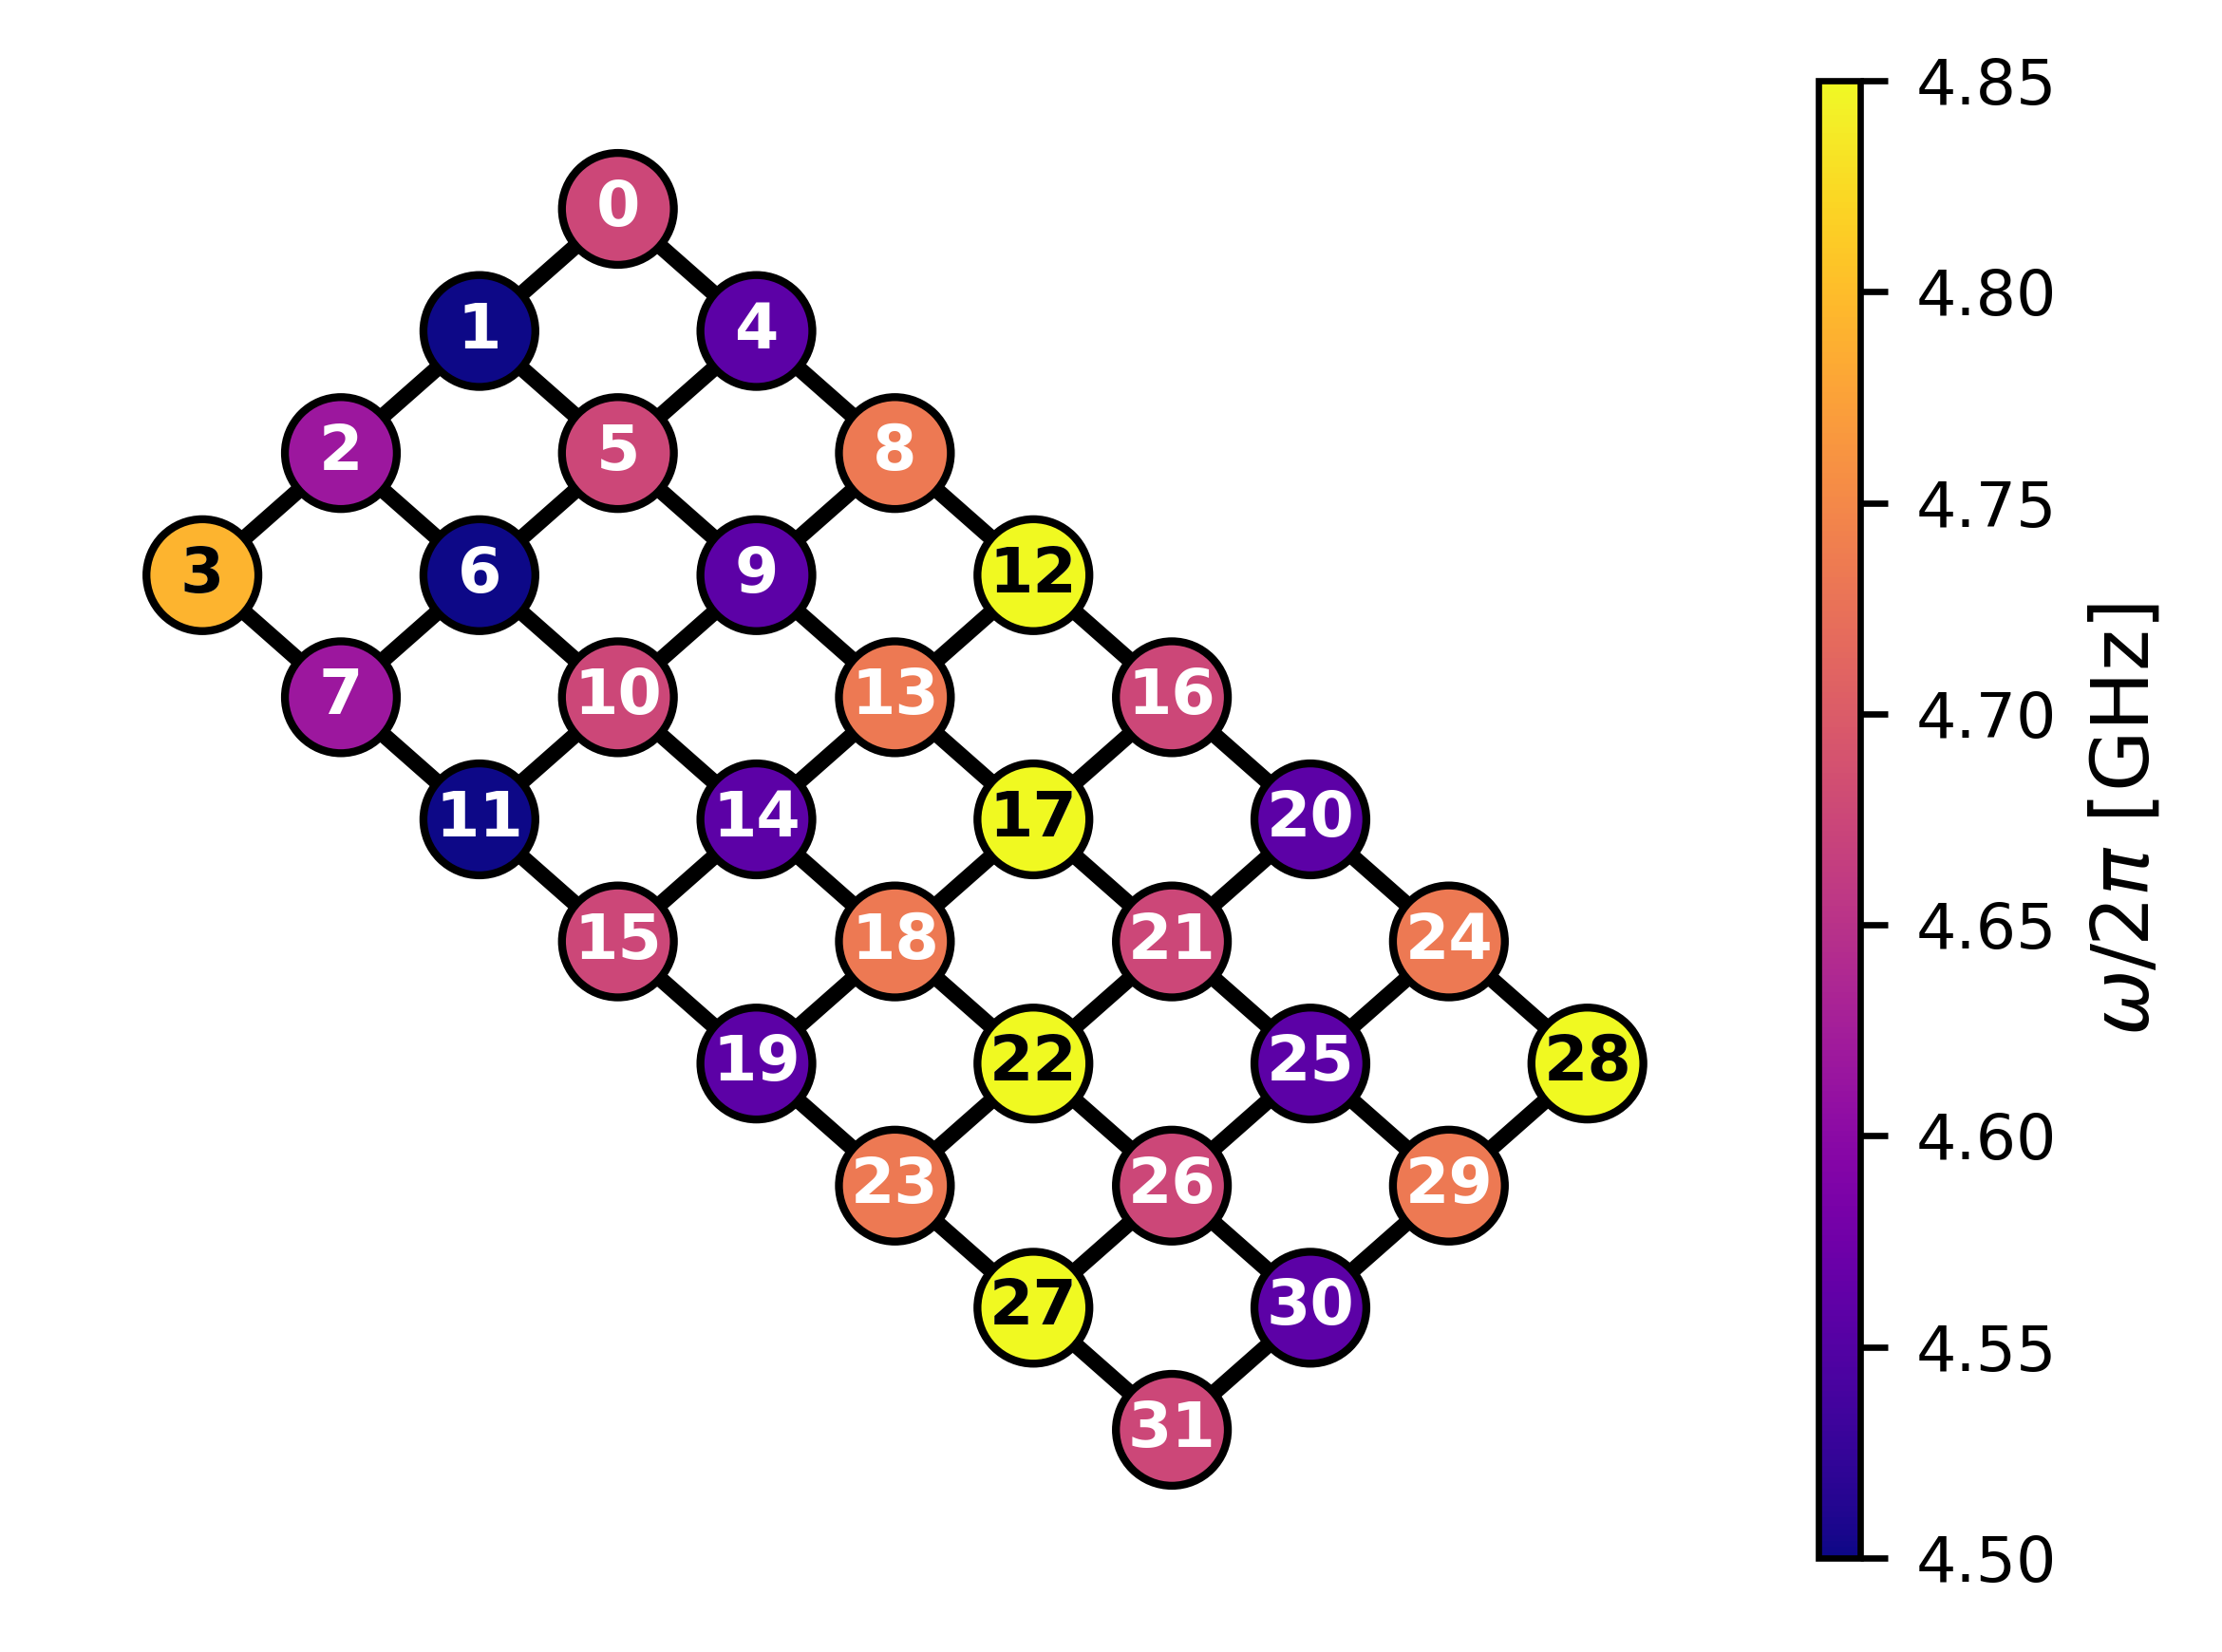

In [10]:
display(Image(filename="Pictures/layout-32q.png", width=700, height=700))

#### 2x2 ring

[Parallel(n_jobs=7)]: Using backend LokyBackend with 7 concurrent workers.


(array([29]), array([0]))
(array([29]), array([0]))
(array([29]), array([0]))
(array([29]), array([0]))
(array([29]), array([0]))
(array([29]), array([0]))
(array([29]), array([0]))
(array([29]), array([0]))
(array([29]), array([0]))
(array([29]), array([0]))
(array([29]), array([0]))
(array([29]), array([0]))
(array([29]), array([0]))
(array([29]), array([0]))


[Parallel(n_jobs=7)]: Done   4 tasks      | elapsed:    4.9s


(array([29]), array([0]))
(array([29]), array([0]))
(array([29]), array([0]))
(array([29]), array([0]))
(array([29]), array([0]))
(array([29]), array([0]))
(array([29]), array([0]))


[Parallel(n_jobs=7)]: Done  11 tasks      | elapsed:    7.5s


...

[Parallel(n_jobs=7)]: Done  27 tasks      | elapsed:   13.0s


(array([29]), array([0]))
(array([29]), array([0]))


[Parallel(n_jobs=7)]: Done  32 out of  40 | elapsed:   15.5s remaining:    3.9s


(array([29]), array([0]))
(array([29]), array([0]))
(array([29]), array([0]))


[Parallel(n_jobs=7)]: Done  37 out of  40 | elapsed:   17.7s remaining:    1.4s
[Parallel(n_jobs=7)]: Done  40 out of  40 | elapsed:   17.9s finished


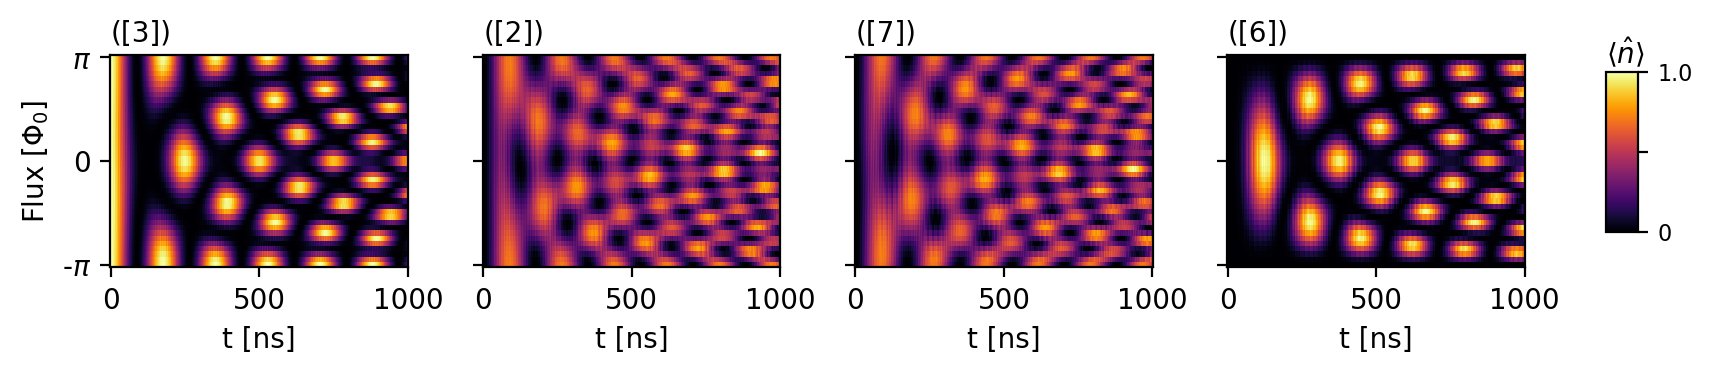

In [6]:
experiment_config_base = {'launch_code': 1,
                          
                    'chosen_sites': [(3,), (2, 7), (6,)],
                    'site_exc_id': [3], 'site_fock_number': [1], 'site_modul_id': [7], 
                    'site_monitor_id_list': [[3], [2], [7], [6]], 'site_monitor_fock_numbers': [[1], [1], [1], [1]],

                    'operating_time_points': np.linspace(0, 1e3, int(1e3 + 1)), # ns
                    'phi_list': [np.linspace(-pi, pi, 40)], 'ef_strength_list': None,

                    'dc_freqs': {},
                    'modul_ampls': {},
                    'modul_freqs': {},
                    'modul_phases': {},

                    'drive_ampl_factor': None,
                    'drive_ampls': {},
                    'drive_freqs': {},
                    'drive_phases': {}}
experiment_config_list = SetUpExperiment(processor, experiment_config_base)

processor.LaunchExperiment(experiment_config_list)

#### 3x3 ring

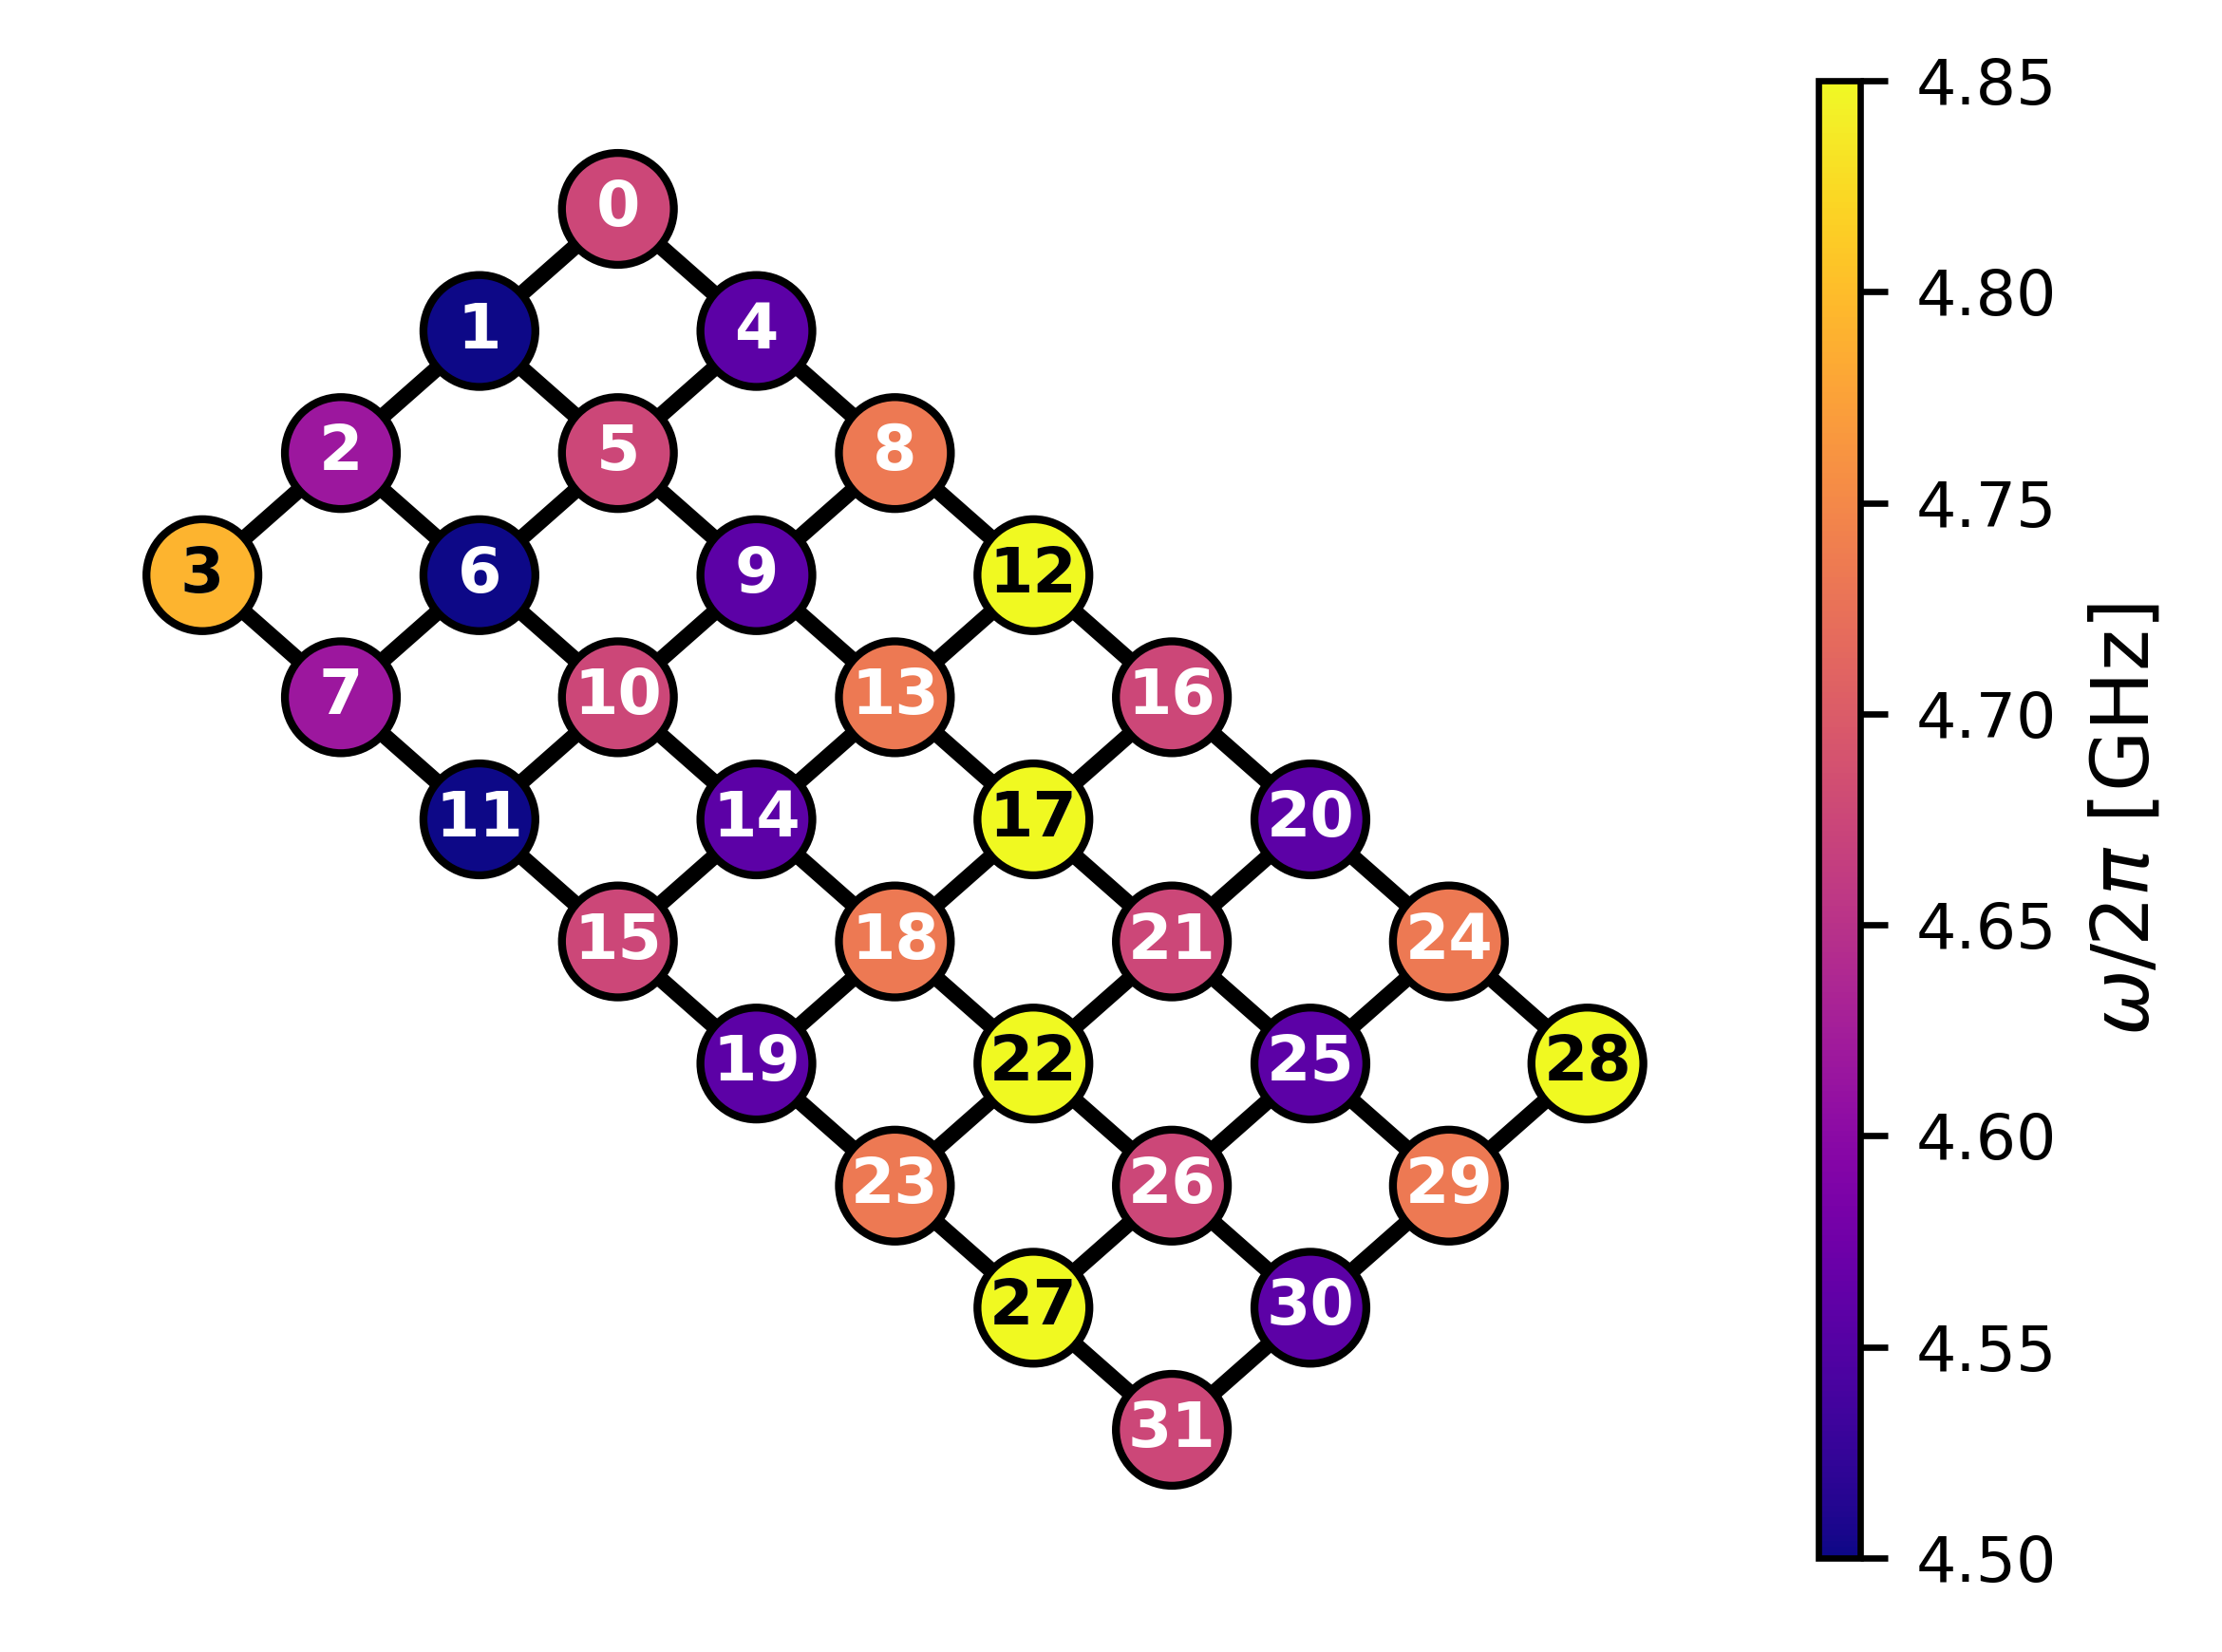

In [ ]:
display(Image(filename="Pictures/layout-32q.png", width=700, height=700))

[Parallel(n_jobs=7)]: Using backend LokyBackend with 7 concurrent workers.
[Parallel(n_jobs=7)]: Done   4 tasks      | elapsed:   11.5s
[Parallel(n_jobs=7)]: Done  11 tasks      | elapsed:   21.1s
[Parallel(n_jobs=7)]: Done  18 tasks      | elapsed:   31.2s
[Parallel(n_jobs=7)]: Done  27 tasks      | elapsed:   42.2s
[Parallel(n_jobs=7)]: Done  32 out of  40 | elapsed:   52.9s remaining:   13.2s
[Parallel(n_jobs=7)]: Done  37 out of  40 | elapsed:  1.0min remaining:    5.0s
[Parallel(n_jobs=7)]: Done  40 out of  40 | elapsed:  1.0min finished


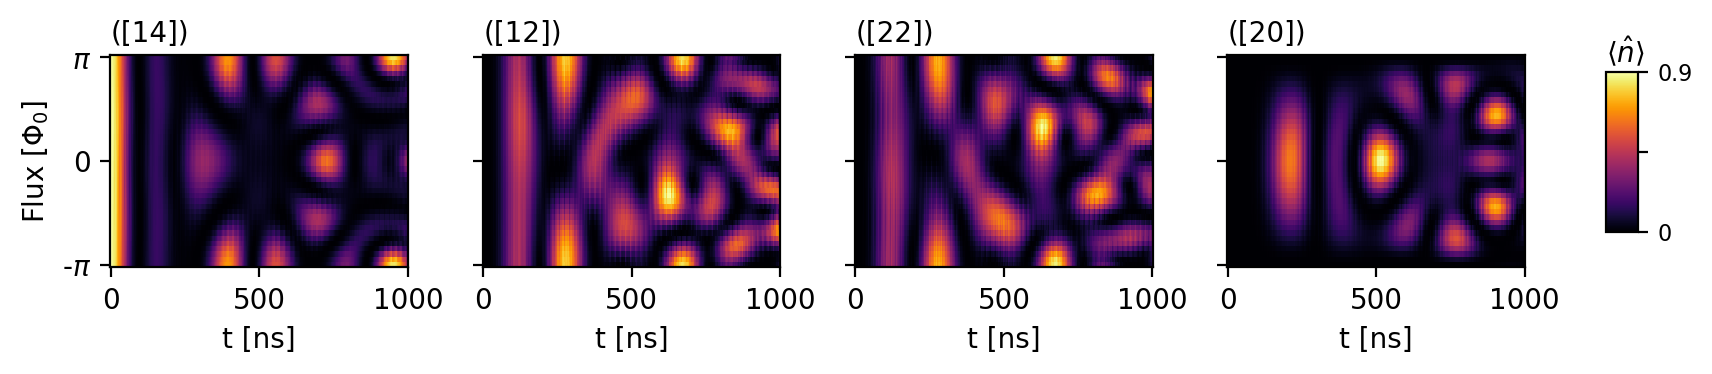

In [5]:
experiment_config_base = {'launch_code': 1,
                          
                    'chosen_sites': [(14,), (13, 18), (12, 22), (16, 21), (20,)],
                    'site_exc_id': [14], 'site_fock_number': [1], 'site_modul_id': [18], 
                    'site_monitor_id_list': [[14], [12], [22], [20]], 'site_monitor_fock_numbers': [[1], [1], [1], [1]],

                    'operating_time_points': np.linspace(0, 1e3, int(1e3 + 1)), # ns
                    'phi_list': [np.linspace(-pi, pi, 40)], 'ef_strength_list': None,

                    'dc_freqs': {},
                    'modul_ampls': {},
                    'modul_freqs': {},
                    'modul_phases': {},

                    'drive_ampl_factor': None,
                    'drive_ampls': {},
                    'drive_freqs': {},
                    'drive_phases': {}}
experiment_config_list = SetUpExperiment(processor, experiment_config_base)

processor.LaunchExperiment(experiment_config_list)

#### 4x4 ring

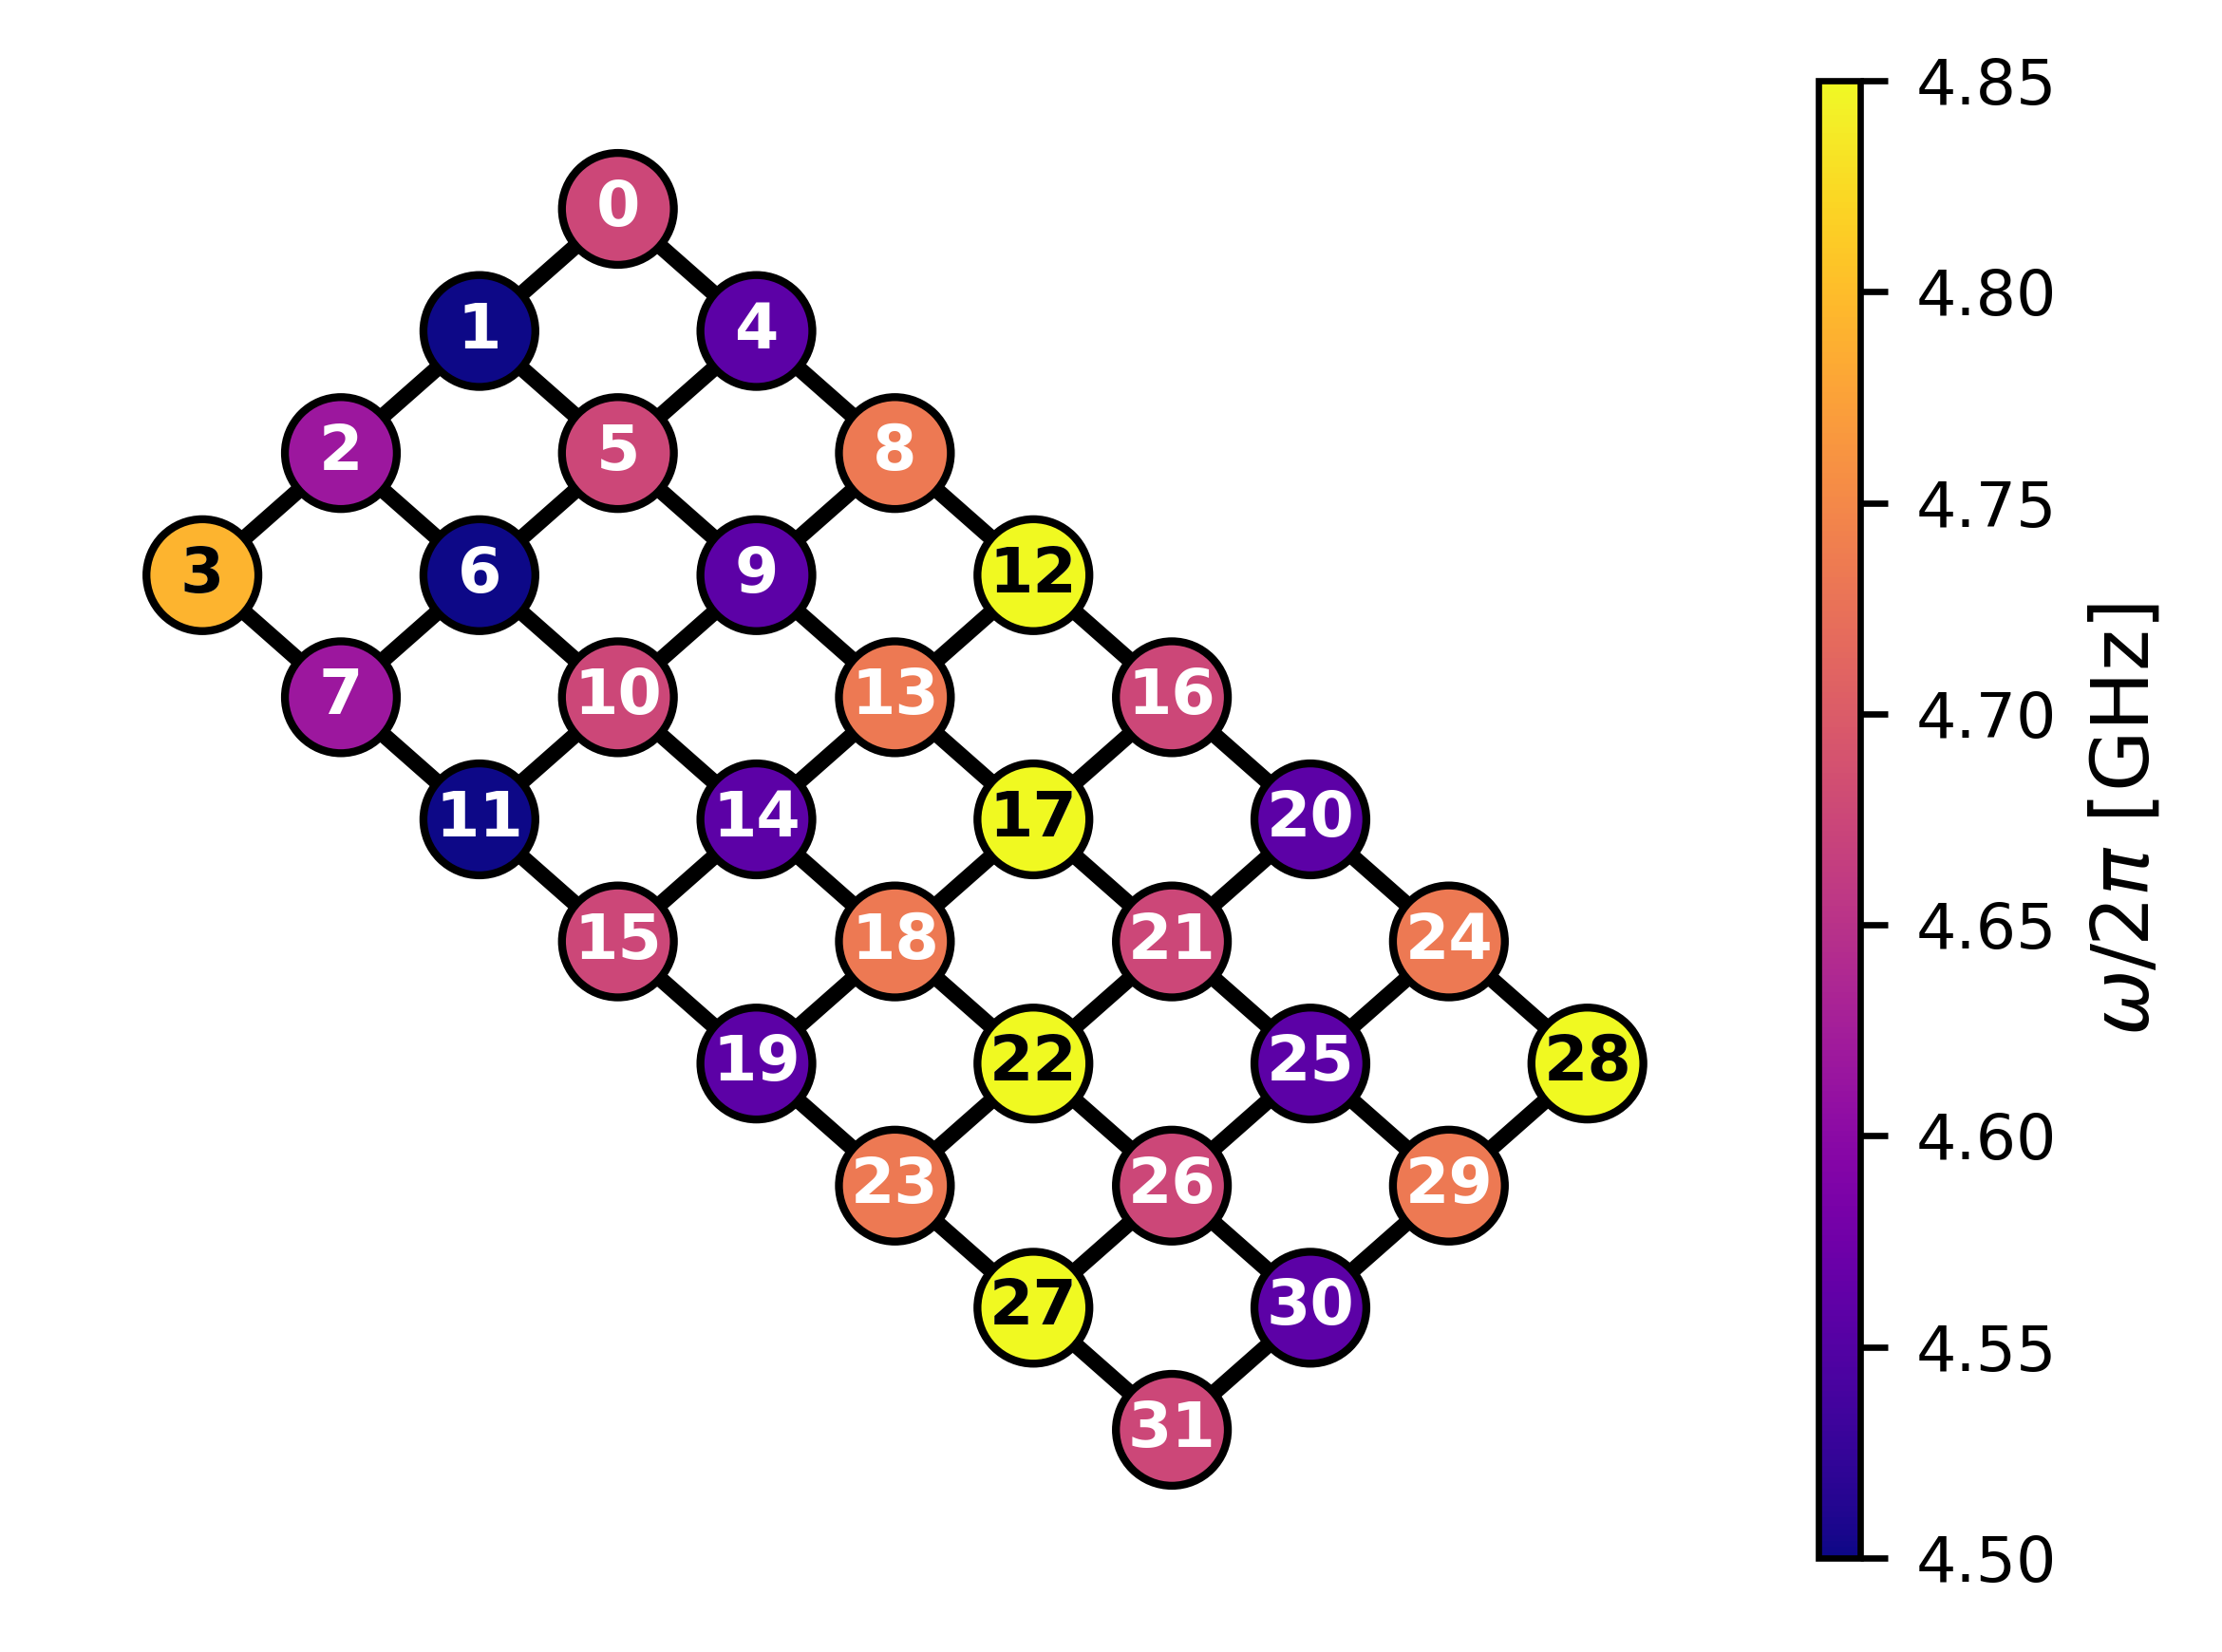

In [ ]:
display(Image(filename="Pictures/layout-32q.png", width=700, height=700))

[Parallel(n_jobs=7)]: Using backend LokyBackend with 7 concurrent workers.
[Parallel(n_jobs=7)]: Done   4 tasks      | elapsed:   12.5s
[Parallel(n_jobs=7)]: Done  11 tasks      | elapsed:   24.0s
[Parallel(n_jobs=7)]: Done  18 tasks      | elapsed:   35.9s
[Parallel(n_jobs=7)]: Done  27 tasks      | elapsed:   49.0s
[Parallel(n_jobs=7)]: Done  32 out of  40 | elapsed:  1.0min remaining:   15.2s
[Parallel(n_jobs=7)]: Done  37 out of  40 | elapsed:  1.2min remaining:    5.8s
[Parallel(n_jobs=7)]: Done  40 out of  40 | elapsed:  1.2min finished


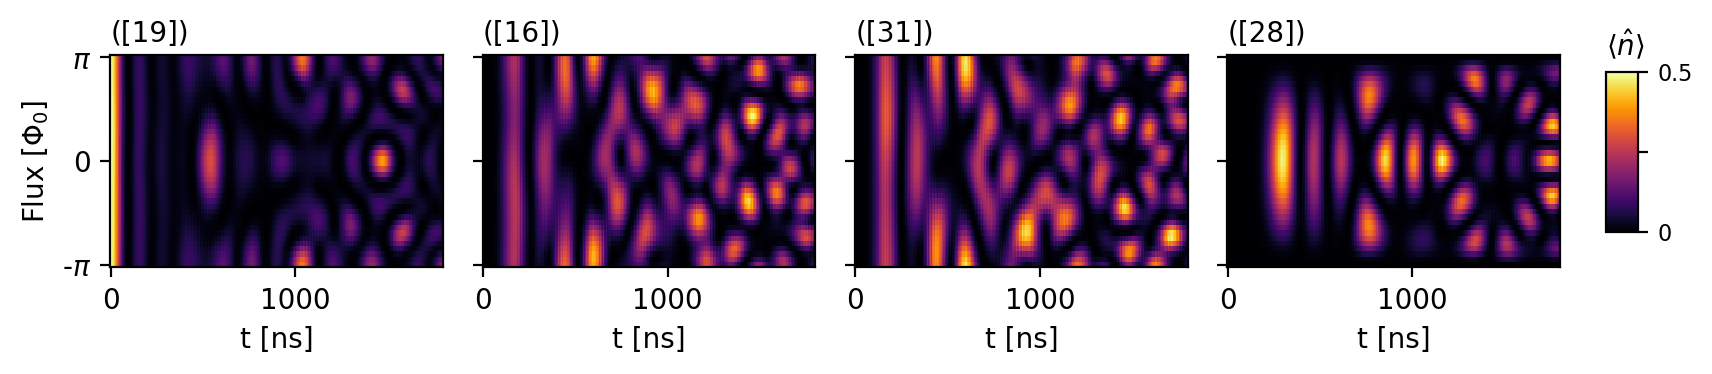

In [7]:
experiment_config_base = {'launch_code': 1,

                    'chosen_sites': [(19,), (18, 23), (17, 27), (16, 31), (20, 30), (24, 29), (28,)],
                    'site_exc_id': [19], 'site_fock_number': [1], 'site_modul_id': [18], 
                    'site_monitor_id_list': [[19], [16], [31], [28]], 'site_monitor_fock_numbers': [[1], [1], [1], [1]],

                    'operating_time_points': np.linspace(0, 1.8e3, int(1.8e3 + 1)), # ns
                    'phi_list': [np.linspace(-pi, pi, 40)], 'ef_strength_list': None,

                    'dc_freqs': {},
                    'modul_ampls': {},
                    'modul_freqs': {},
                    'modul_phases': {},

                    'drive_ampl_factor': None,
                    'drive_ampls': {},
                    'drive_freqs': {},
                    'drive_phases': {}}
experiment_config_list = SetUpExperiment(processor, experiment_config_base)

processor.LaunchExperiment(experiment_config_list)

#### 14q in a ring

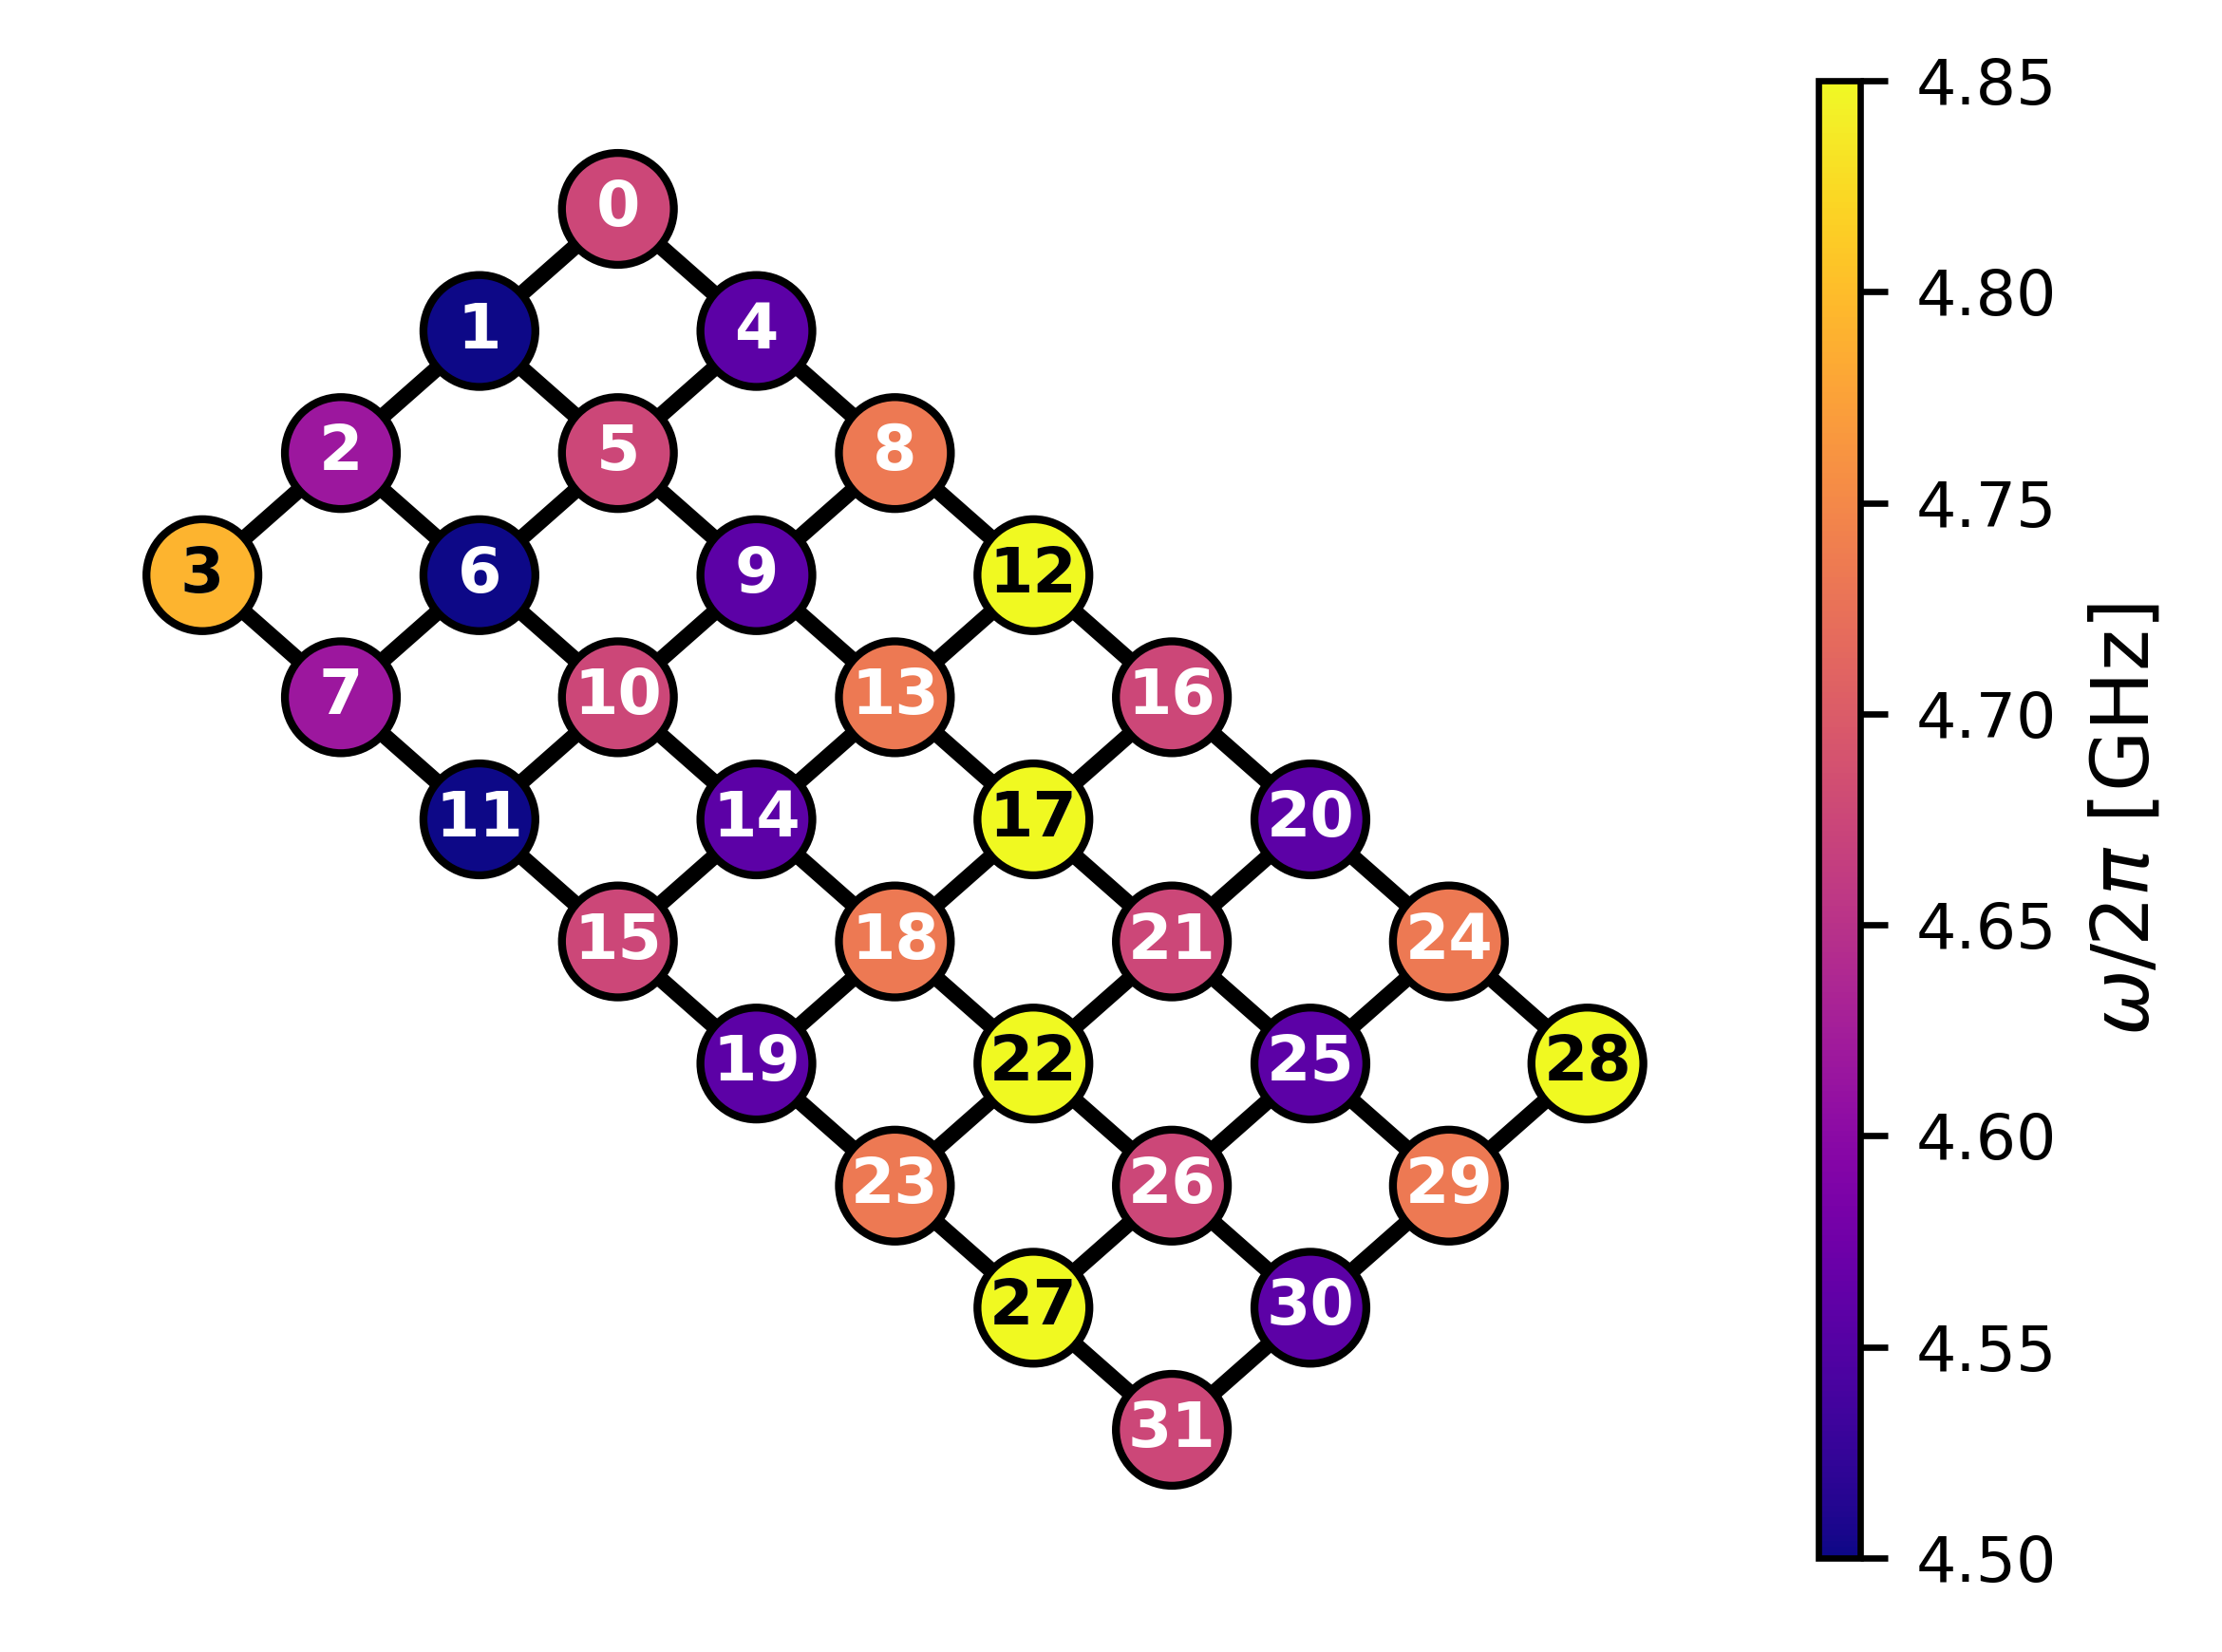

In [ ]:
display(Image(filename="Pictures/layout-32q.png", width=700, height=700))

[Parallel(n_jobs=7)]: Using backend LokyBackend with 7 concurrent workers.
[Parallel(n_jobs=7)]: Done   4 tasks      | elapsed:   16.0s
[Parallel(n_jobs=7)]: Done  11 tasks      | elapsed:   33.6s
[Parallel(n_jobs=7)]: Done  18 tasks      | elapsed:   52.3s
[Parallel(n_jobs=7)]: Done  27 tasks      | elapsed:  1.2min
[Parallel(n_jobs=7)]: Done  32 out of  40 | elapsed:  1.5min remaining:   23.1s
[Parallel(n_jobs=7)]: Done  37 out of  40 | elapsed:  1.8min remaining:    8.7s
[Parallel(n_jobs=7)]: Done  40 out of  40 | elapsed:  1.8min finished


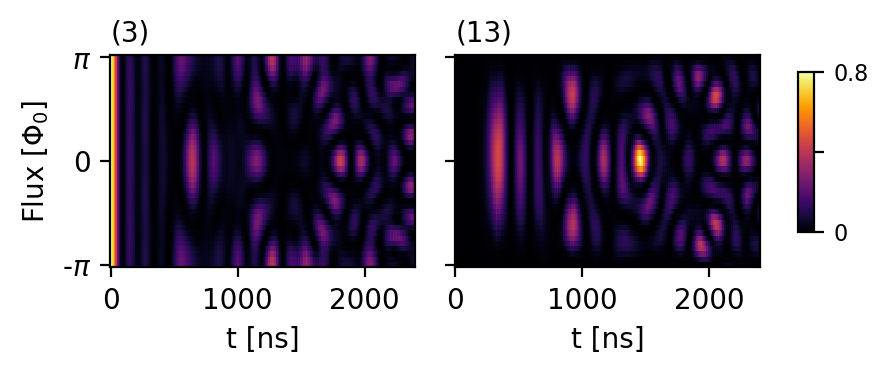

In [ ]:
experiment_config_base = {'launch_code': 1,
                          
                    'chosen_sites': [(3,), (2, 7), (1, 11), (0, 15), (4, 9, 19), (8, 13, 18), (17,)],
                    'site_exc_id': [3], 'site_modul_id': 11, 
                    'site_monitor_id_list': [3, 13],

                    'operating_time_points': np.linspace(0, 2.4e3, int(2.4e3 + 1)), # ns
                    'phi_list': np.linspace(-pi, pi, 40), 'ef_strength_list': None,

                    'dc_freqs': {},
                    'modul_ampls': {},
                    'modul_freqs': {},
                    'modul_phases': {},

                    'drive_ampl_factor': None,
                    'drive_ampls': {},
                    'drive_freqs': {},
                    'drive_phases': {}}
experiment_config_list = SetUpExperiment(processor, experiment_config_base)

processor.LaunchExperiment(experiment_config_list)

#### 22q in a ring

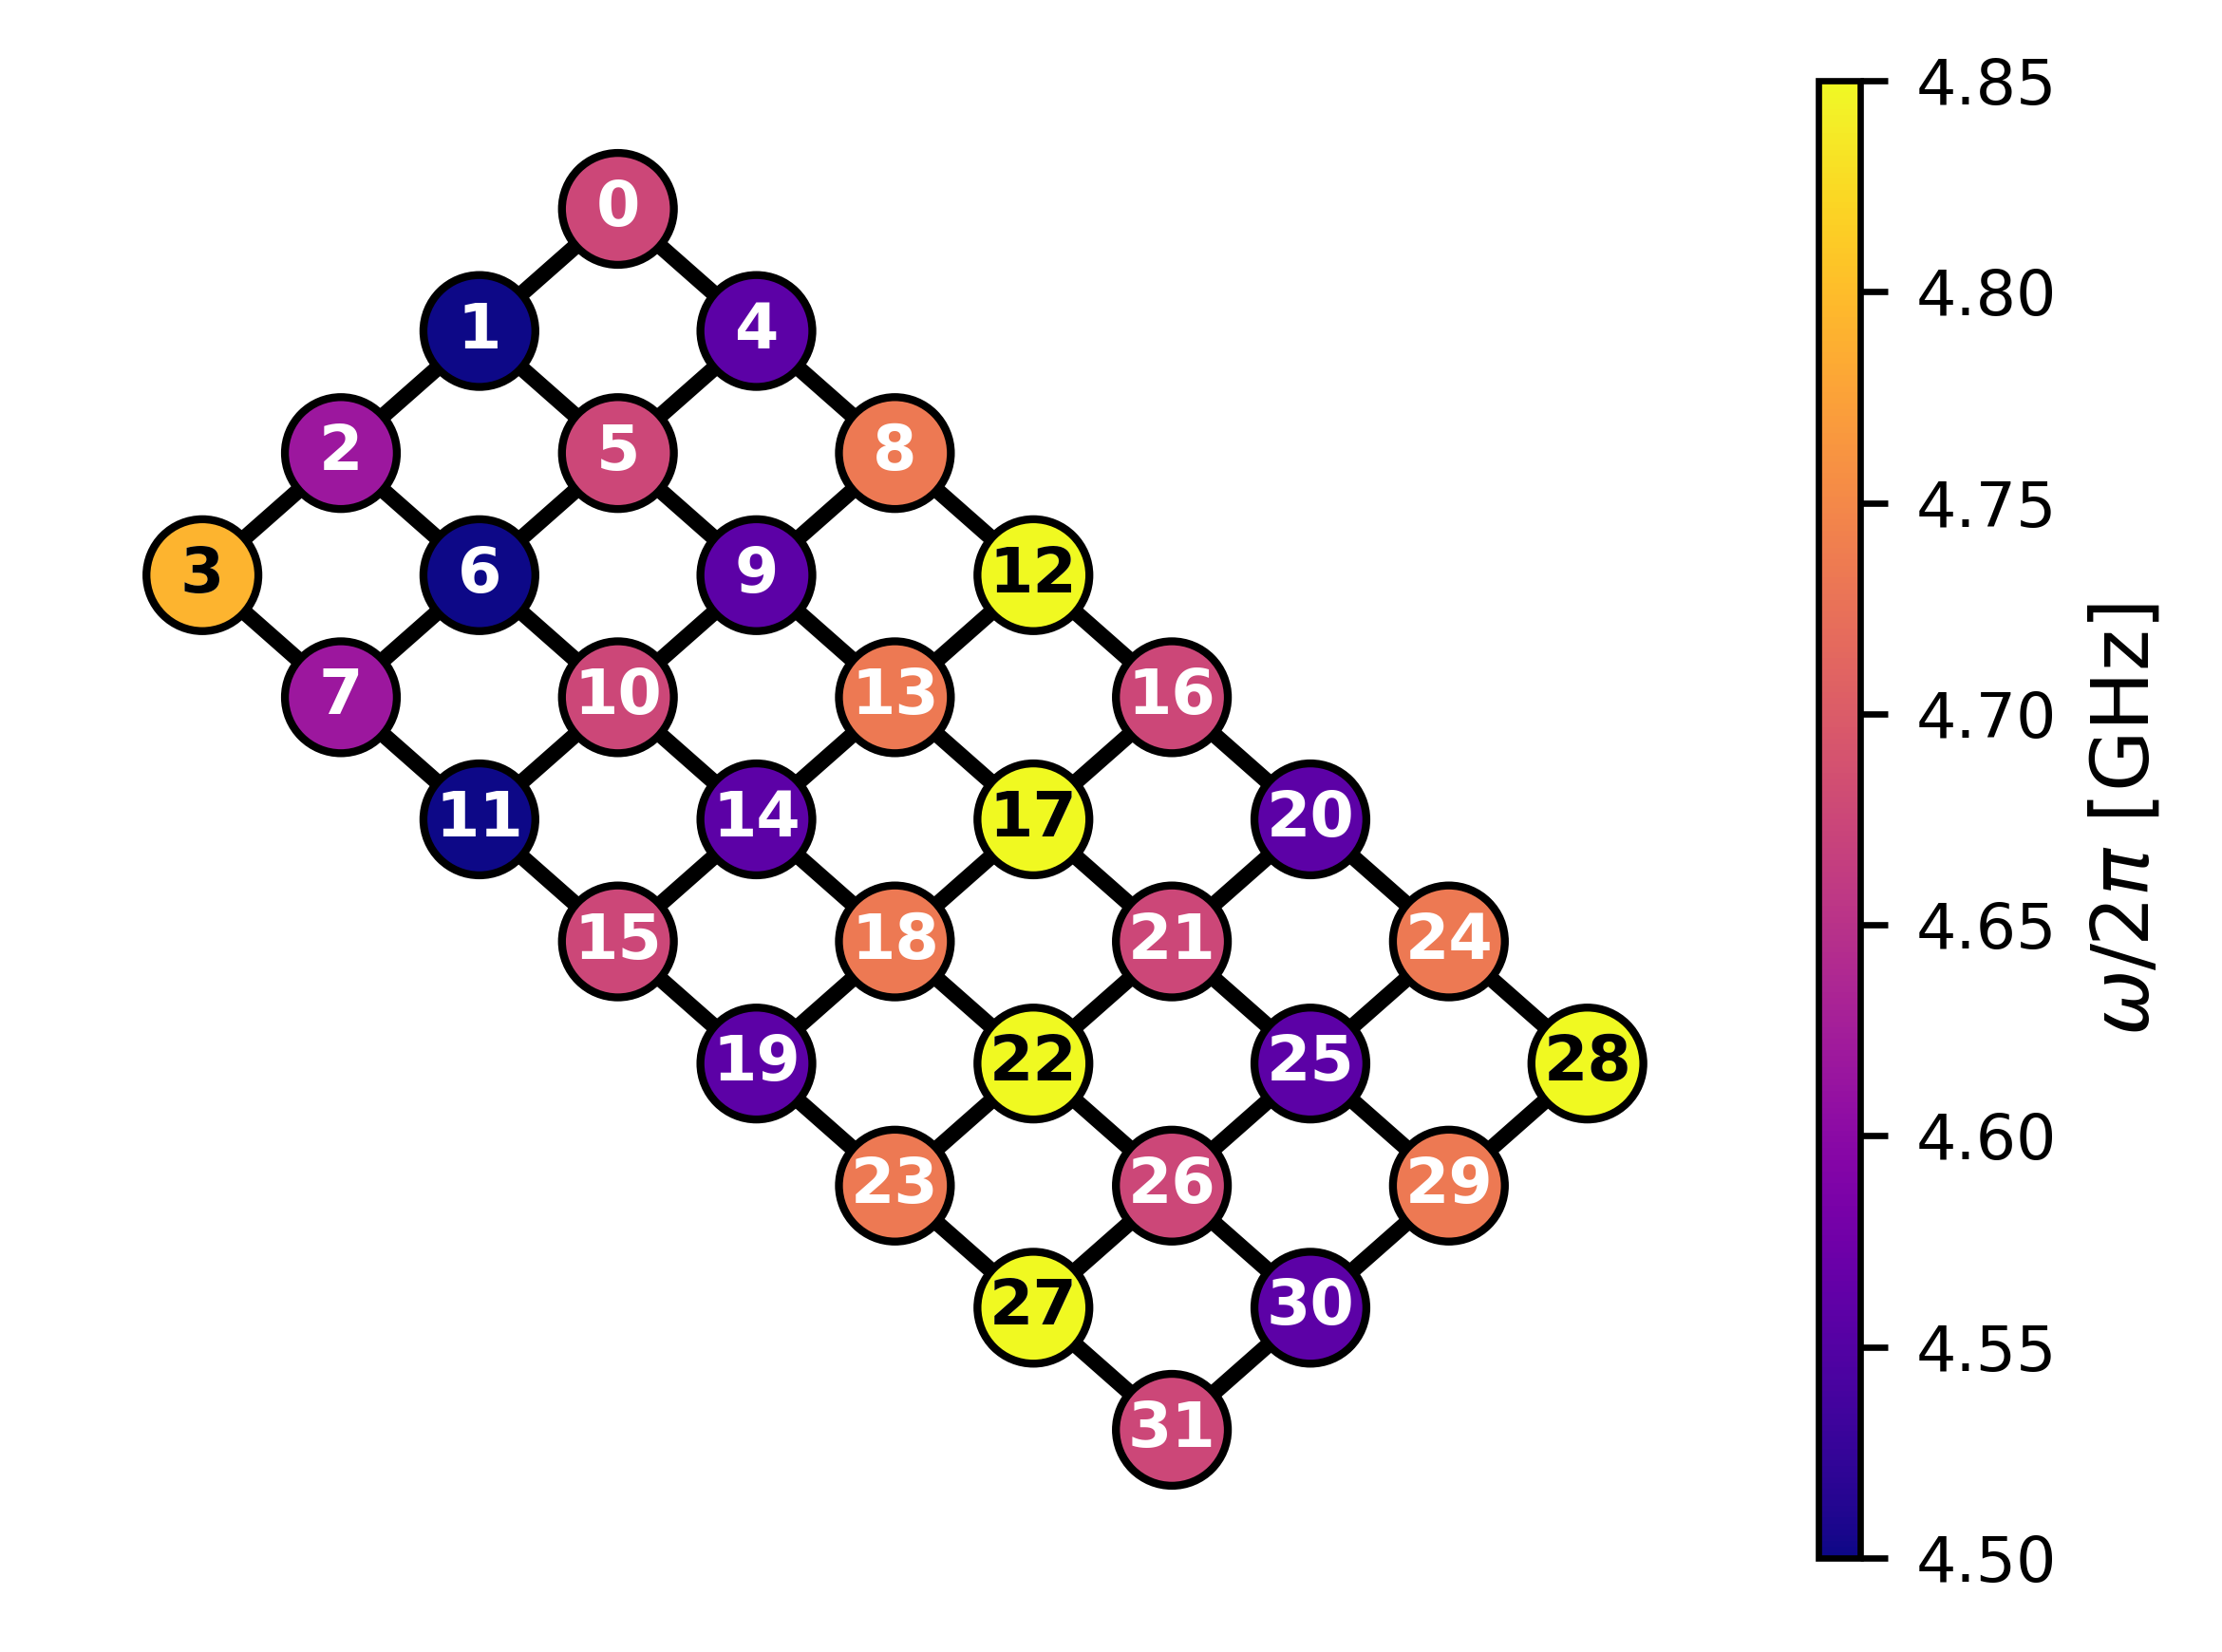

In [ ]:
display(Image(filename="Pictures/layout-32q.png", width=700, height=700))

[Parallel(n_jobs=7)]: Using backend LokyBackend with 7 concurrent workers.
[Parallel(n_jobs=7)]: Done   4 tasks      | elapsed:   31.7s
[Parallel(n_jobs=7)]: Done  11 tasks      | elapsed:  1.1min
[Parallel(n_jobs=7)]: Done  18 tasks      | elapsed:  1.7min
[Parallel(n_jobs=7)]: Done  27 tasks      | elapsed:  2.4min
[Parallel(n_jobs=7)]: Done  32 out of  40 | elapsed:  3.0min remaining:   45.2s
[Parallel(n_jobs=7)]: Done  37 out of  40 | elapsed:  3.5min remaining:   17.2s
[Parallel(n_jobs=7)]: Done  40 out of  40 | elapsed:  3.6min finished


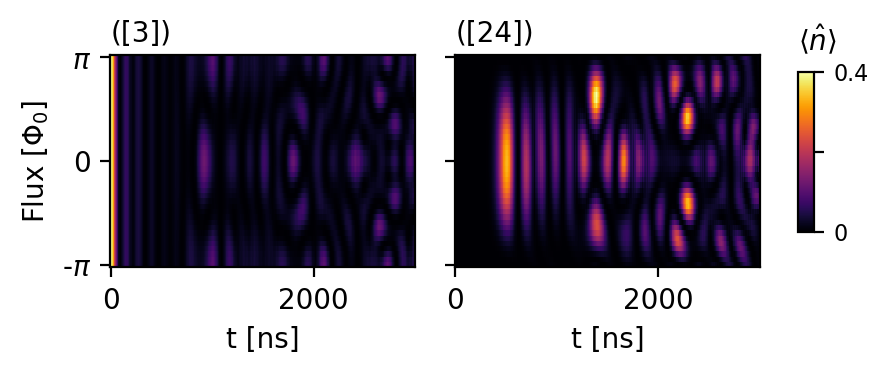

In [ ]:
experiment_config_base = {'launch_code': 1,
                          
                    'chosen_sites': [(3,), (2, 7), (1, 11), (0, 15), (4, 9, 19), (8, 13, 23), (17, 27), (16, 31), (20, 25, 30), (24, 29)],
                    'site_exc_id': [3], 'site_fock_number': [1], 'site_modul_id': [16], 
                    'site_monitor_id_list': [[3], [24]], 'site_monitor_fock_numbers': [[1], [1]],

                    'operating_time_points': np.linspace(0, 3e3, int(3e3 + 1)), # ns
                    'phi_list': [np.linspace(-pi, pi, 40)], 'ef_strength_list': None,

                    'dc_freqs': {},
                    'modul_ampls': {},
                    'modul_freqs': {},
                    'modul_phases': {},

                    'drive_ampl_factor': None,
                    'drive_ampls': {},
                    'drive_freqs': {},
                    'drive_phases': {}}
experiment_config_list = SetUpExperiment(processor, experiment_config_base)

processor.LaunchExperiment(experiment_config_list)

### Faraday's law

The reason why if we initialize particle not in the center of the 1D chain we can observe separate locations of localized population is because we have qubits with the same dc-frequency in this chain. Excitation in the center simulates particle in infinite lattice!

- base: bloch oscillations with 1 excitation ✅ <br>

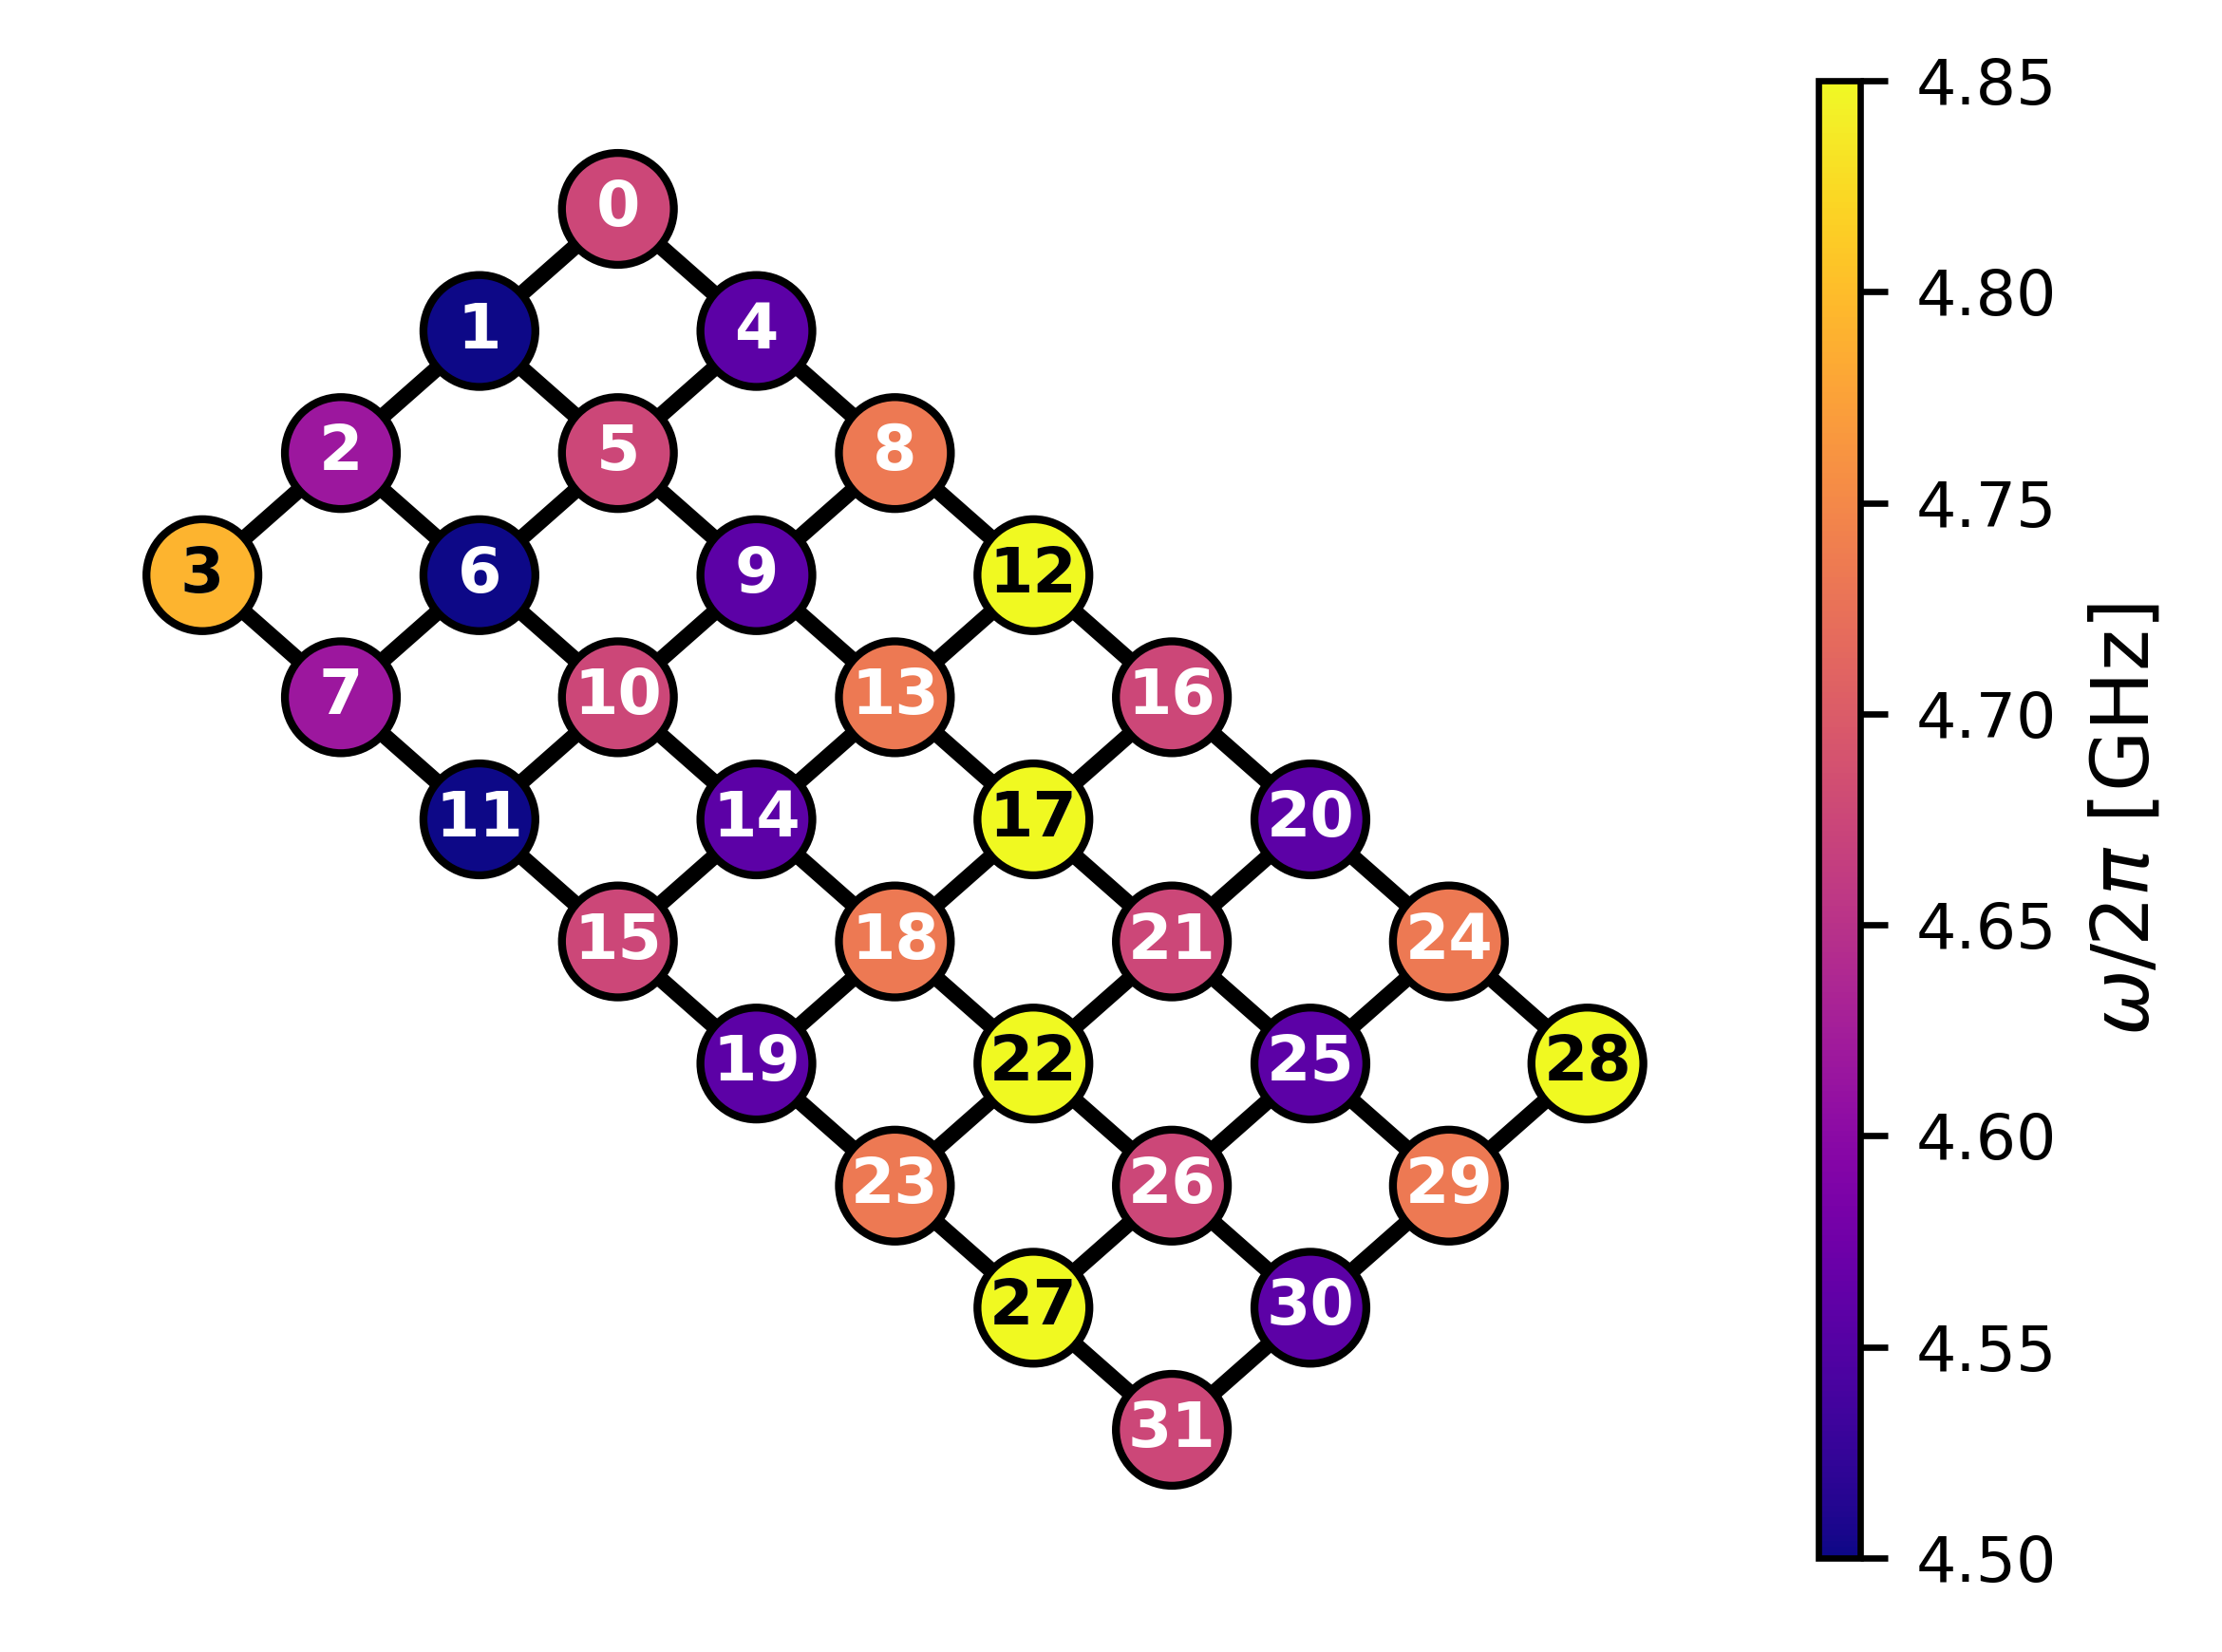

In [ ]:
display(Image(filename="Pictures/layout-32q.png", width=700, height=700))

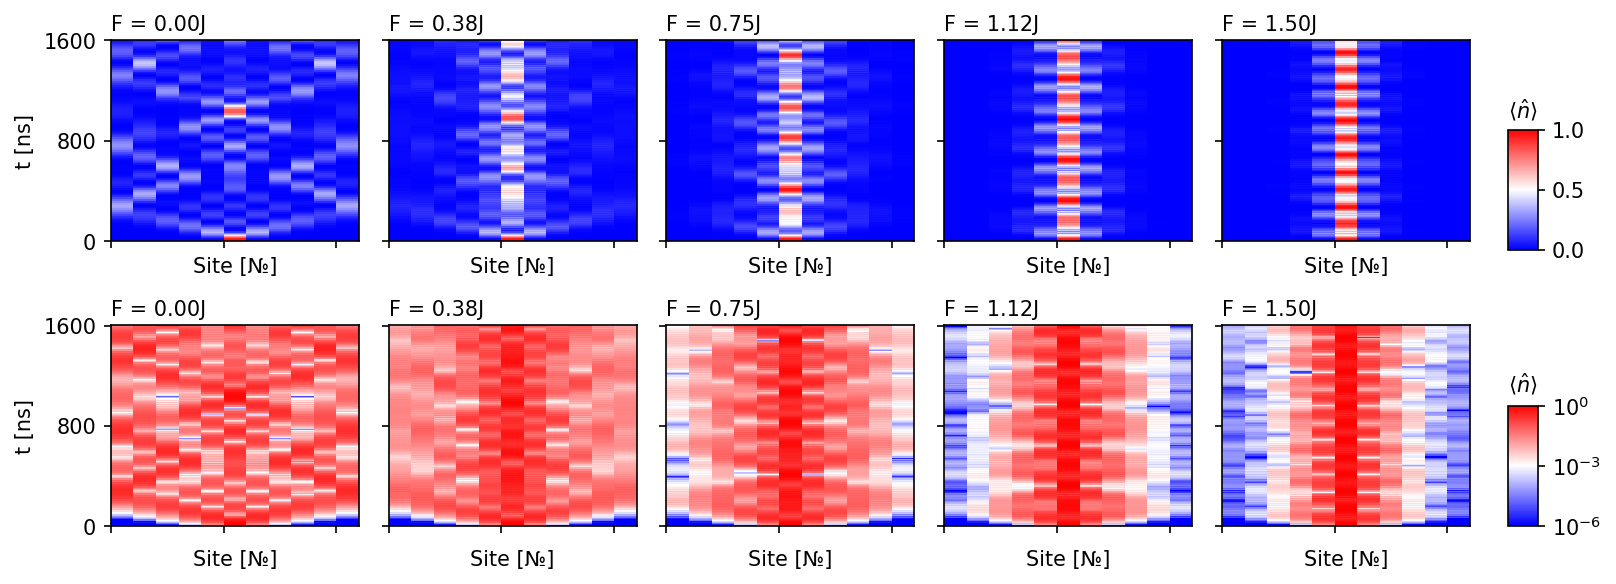

In [7]:
experiment_config_base = {'launch_code': 2,

                    'chosen_sites': [(15,), (14, 19), (13, 23), (12, 27), (16, 26), (20, 25)],
                    'site_exc_id': [15], 'site_fock_number': [1], 'site_modul_id': None,
                    'site_monitor_id_list': [20, 16, 12, 13, 14, 15, 19, 23, 27, 26, 25],

                    'operating_time_points': np.linspace(0, 16e2, int(16e2 + 1)), # ns
                    'phi_list': None, 'ef_strength_list': np.linspace(0, 1.5, 5),

                    'dc_freqs': {},
                    'modul_ampls': {},
                    'modul_freqs': {},
                    'modul_phases': {},

                    'drive_ampl_factor': None,
                    'drive_ampls': {},
                    'drive_freqs': {},
                    'drive_phases': {}}
experiment_config_list = SetUpExperiment(processor, experiment_config_base)

processor.LaunchExperiment(experiment_config_list)

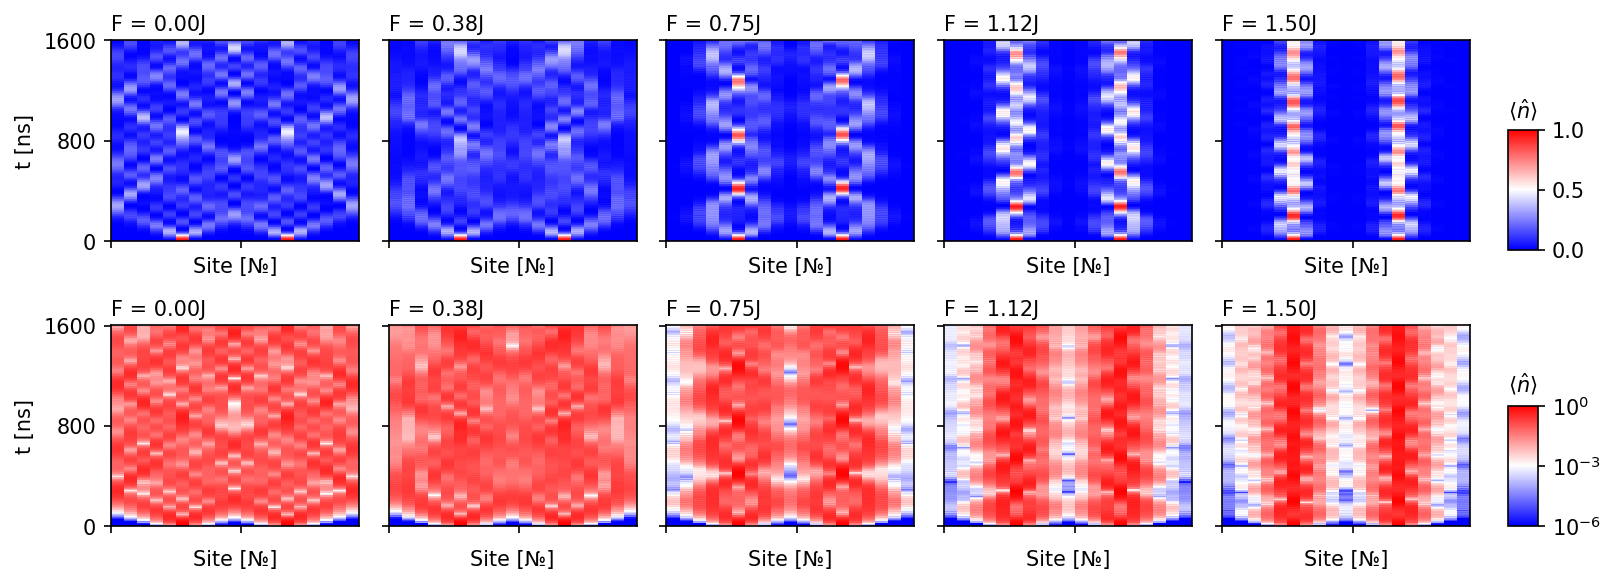

In [4]:
experiment_config_base = {'launch_code': 2,

                    'chosen_sites': [(3,), (2, 7), (1, 11), (5, 15), (9, 14), (8, 18), (12, 22), (16, 26), (20, 30), (24, 29)],
                    'site_exc_id': [9, 14], 'site_fock_number': [1, 1], 'site_modul_id': None,
                    'site_monitor_id_list': [24, 20, 16, 12, 8, 9, 5, 1, 2, 3, 7, 11, 15, 14, 18, 22, 26, 30, 29],

                    'operating_time_points': np.linspace(0, 16e2, int(16e2 + 1)), # ns
                    'phi_list': None, 'ef_strength_list': np.linspace(0, 1.5, 5),

                    'dc_freqs': {},
                    'modul_ampls': {},
                    'modul_freqs': {},
                    'modul_phases': {},

                    'drive_ampl_factor': None,
                    'drive_ampls': {},
                    'drive_freqs': {},
                    'drive_phases': {}}
experiment_config_list = SetUpExperiment(processor, experiment_config_base)

processor.LaunchExperiment(experiment_config_list)

- If there is asymmetry in how many qubits with frequency that is the frequency of initial excited qubit on the left and on the right, then excitation tends to localize in each of such qubit partially with increasing e-field <br>
- for two excitations that are initialized symmetrical regarding center of the chain it seems like there is different influence of the field on left and right part of the chain

Giving layout of dc freqs of qubits it is clear that if we start with excitation on 7th qubit then with high enough el field excitation swaps between 7th & 2nd qubit cuz their dc freqs & driving signals coincide

### Hall effect

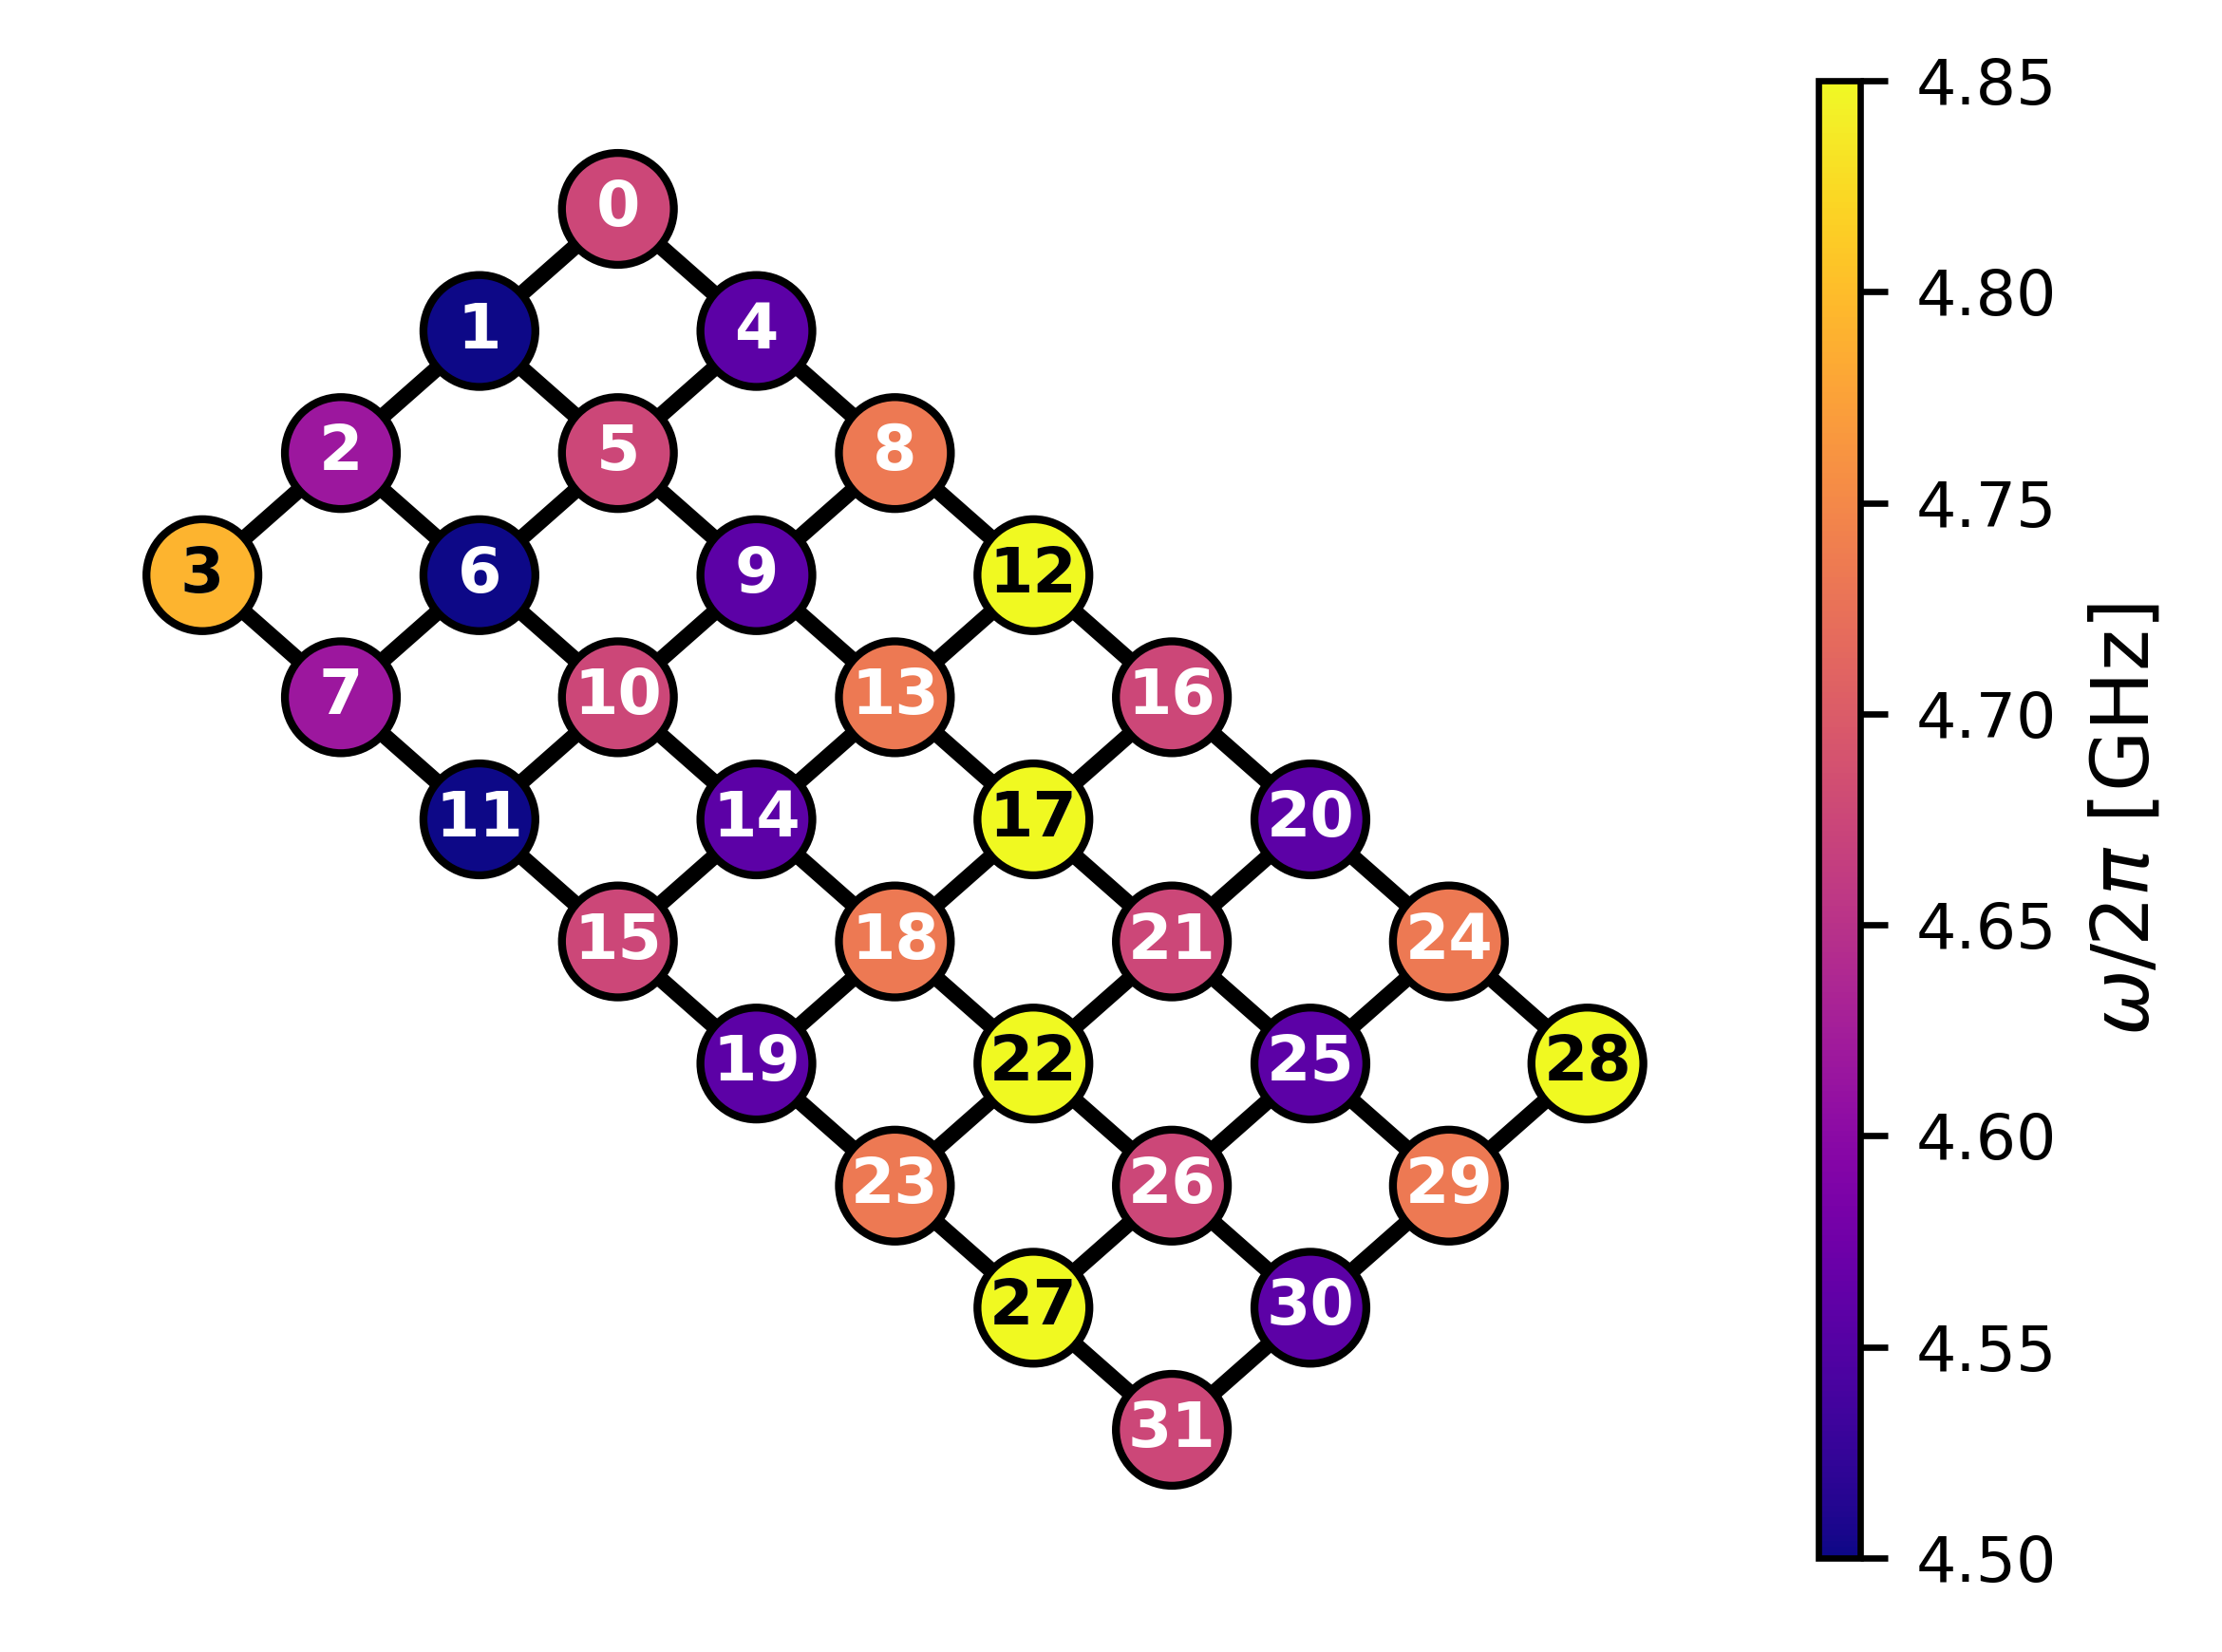

In [ ]:
display(Image(filename="Pictures/layout-32q.png", width=700, height=700))

#### Particle dynamics

[Parallel(n_jobs=7)]: Using backend LokyBackend with 7 concurrent workers.
[Parallel(n_jobs=7)]: Done   4 out of  11 | elapsed:    3.3s remaining:    5.8s
[Parallel(n_jobs=7)]: Done   7 out of  11 | elapsed:    4.1s remaining:    2.3s
[Parallel(n_jobs=7)]: Done  11 out of  11 | elapsed:    5.2s finished


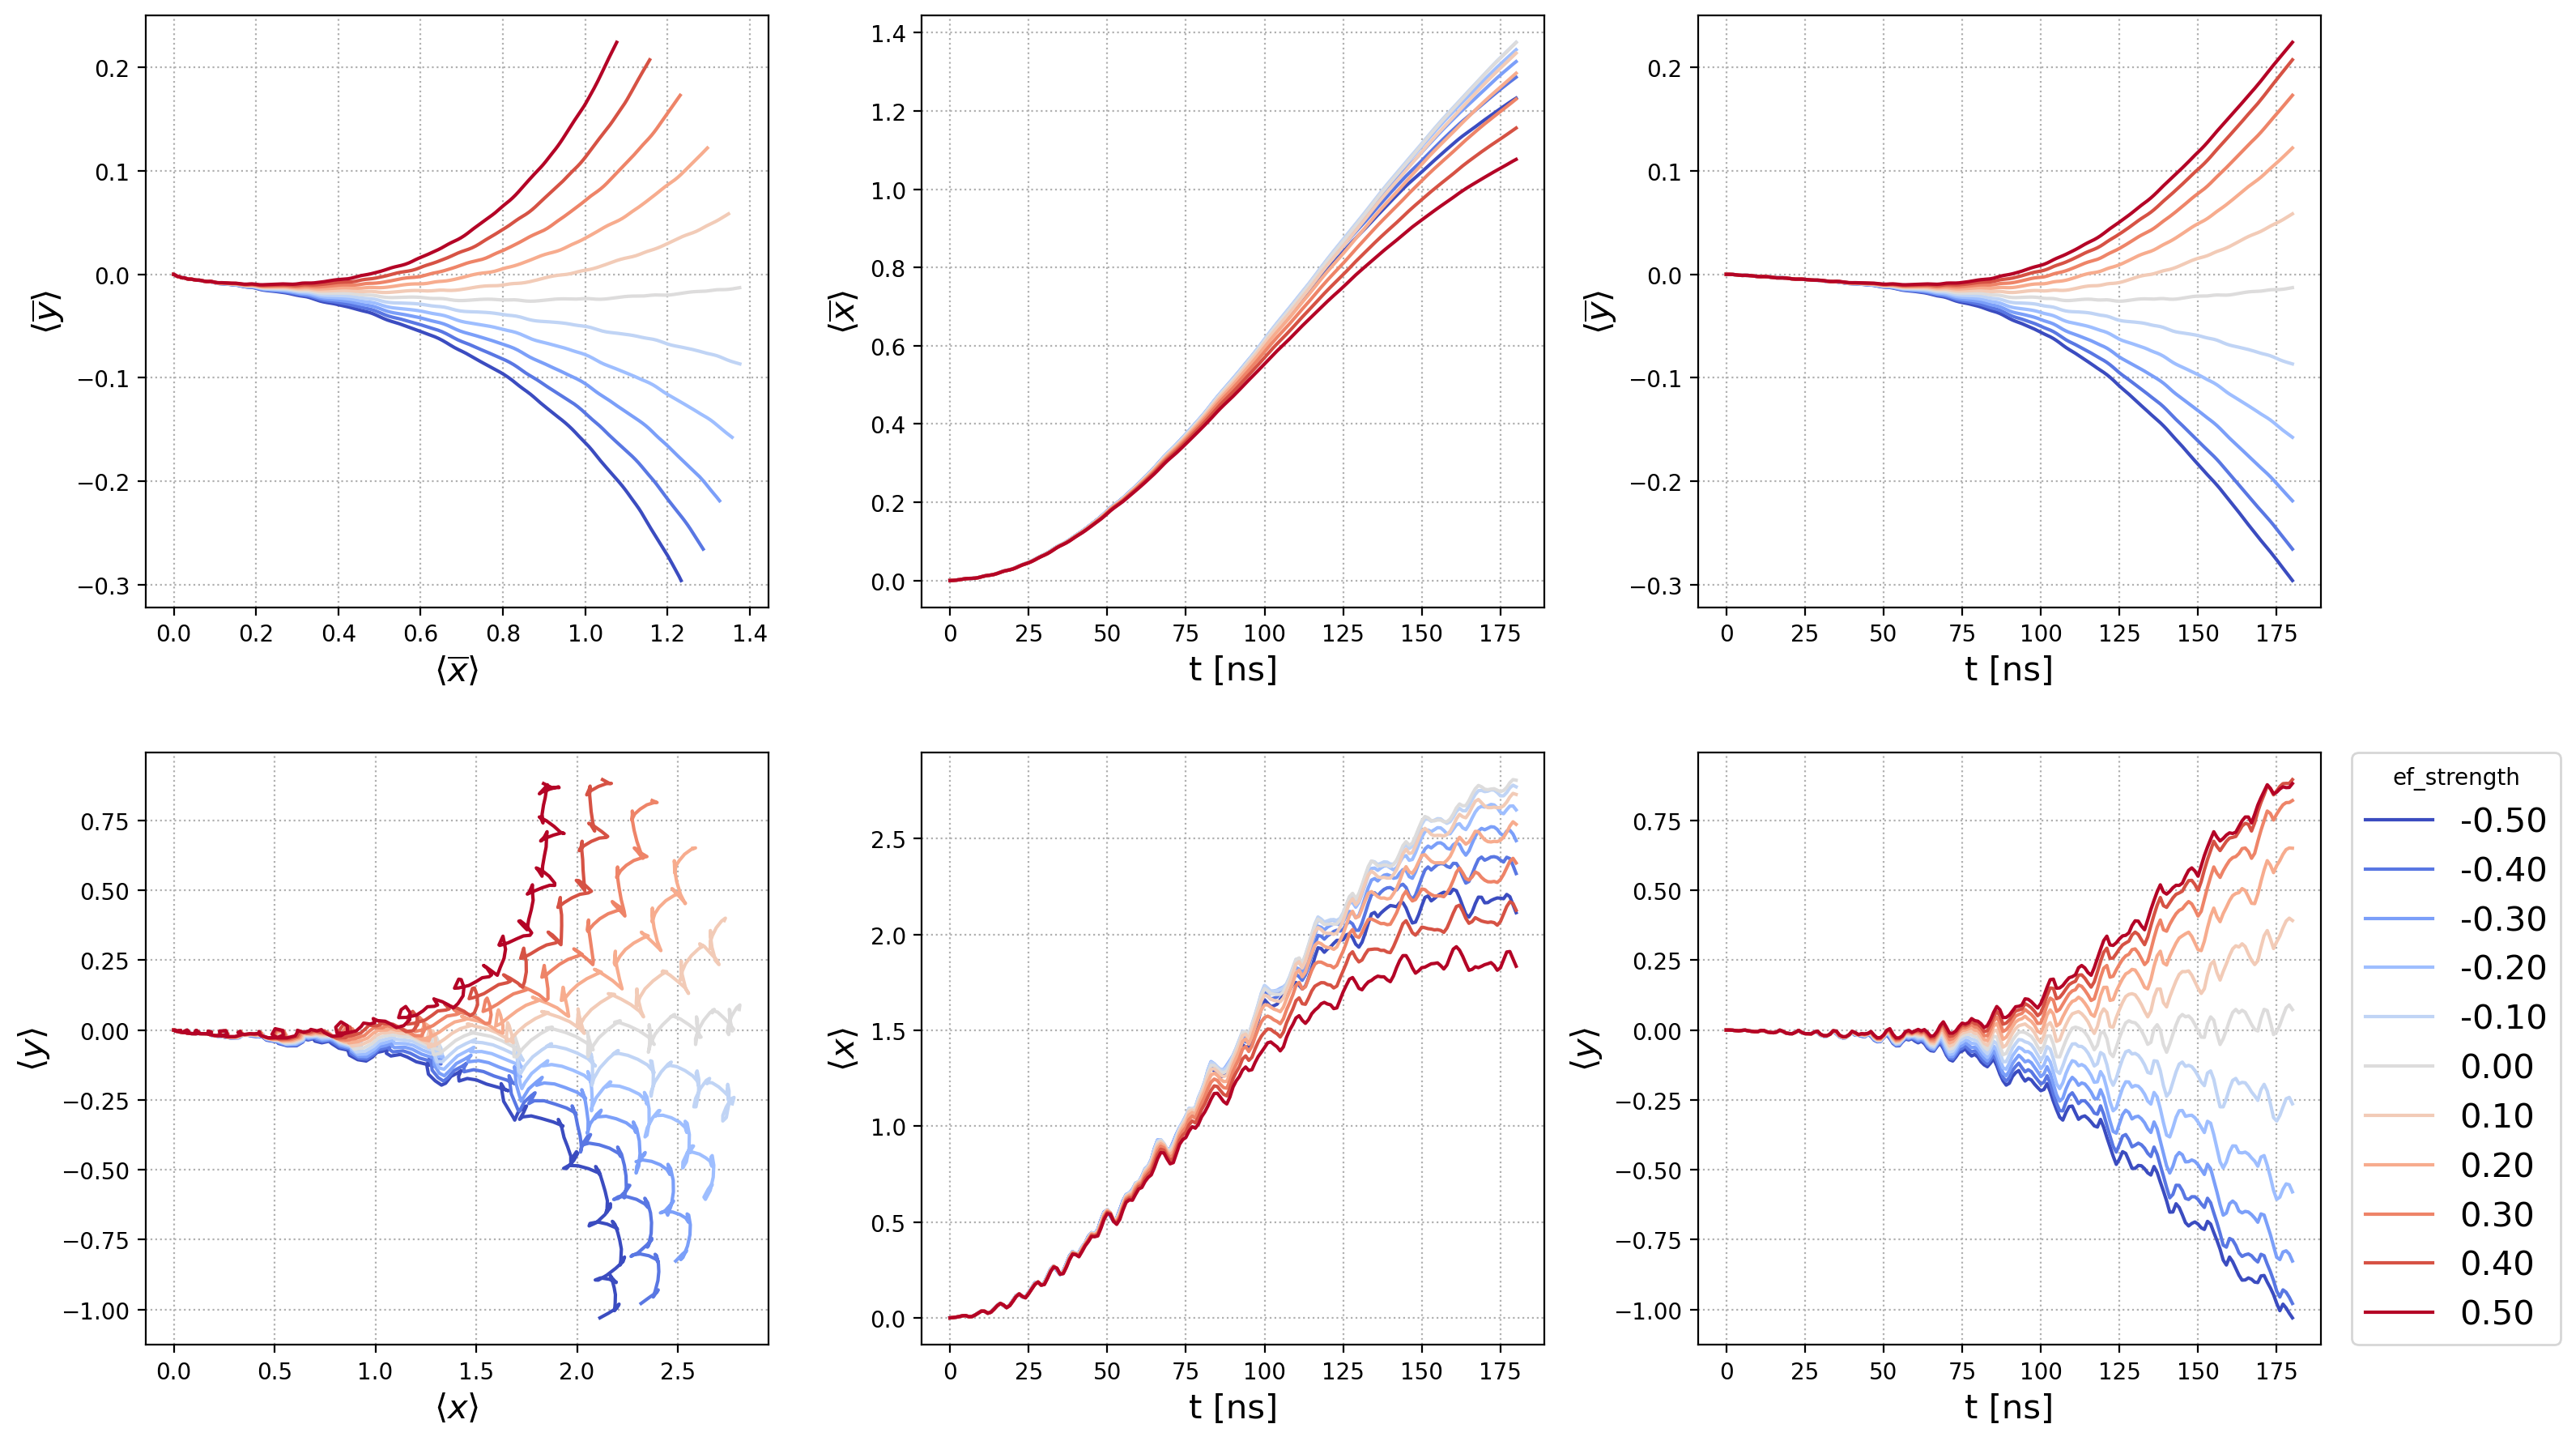

In [5]:
Phi = pi / 12

experiment_config_base = {'launch_code': 4,

                    'chosen_sites': [(3,), (2, 7), (1, 6, 11), (0, 5, 10, 15), (4, 9, 14), (8, 13), (12,)],
                    'site_exc_id': [3], 'site_fock_number': [1], 'site_modul_id': None, 
                    'site_monitor_id_list': [3, 2, 1, 0, 7, 6, 5, 4, 11, 10, 9, 8, 15, 14, 13, 12],

                    'operating_time_points': np.linspace(0, 1.8e2, int(1.8e2 + 1)), # ns
                    'phi_list': [Phi], 'ef_strength_list': np.linspace(-0.5, 0.5, 11),

                    'dc_freqs': {},
                    'modul_ampls': {},
                    'modul_freqs': {},
                    'modul_phases': {},

                    'drive_ampl_factor': None,
                    'drive_ampls': {},
                    'drive_freqs': {},
                    'drive_phases': {}}
experiment_config_list = SetUpExperiment(processor, experiment_config_base)

processor.LaunchExperiment(experiment_config_list)

Successfully simulates idealized Harper-Hofstadter model. Due to disorder trajectories shift with time from their idealized paths. Mb compare them with ideal HH? (just change hamiltonian)

In [ ]:
from IPython.display import display, HTML, Image

display(
HTML(f"""
<div style="display:flex; gap:10px;">
    <img src="Pictures/choice-of-gauge-4x4.jpg" width="400" height="300">
    <img src="Pictures/axes-4x4.png" width="300" height="300">
</div>
"""),
HTML(f"""
<div style="display:flex; gap:10px;">
    <img src="Pictures/freqs-layout-4x4.png" width="400" height="300">
    <img src="Pictures/plaquette-4x4.png" width="300" height="300">
</div>
""")
)



They have mistakes in signing phases on edges.

#### Hall coefficients

[Parallel(n_jobs=7)]: Using backend LokyBackend with 7 concurrent workers.
[Parallel(n_jobs=7)]: Done  21 out of  21 | elapsed:    7.8s finished
[Parallel(n_jobs=7)]: Using backend LokyBackend with 7 concurrent workers.
[Parallel(n_jobs=7)]: Done  21 out of  21 | elapsed:    8.1s finished
[Parallel(n_jobs=7)]: Using backend LokyBackend with 7 concurrent workers.
[Parallel(n_jobs=7)]: Done  21 out of  21 | elapsed:    8.4s finished
[Parallel(n_jobs=7)]: Using backend LokyBackend with 7 concurrent workers.
[Parallel(n_jobs=7)]: Done  21 out of  21 | elapsed:    8.7s finished
[Parallel(n_jobs=7)]: Using backend LokyBackend with 7 concurrent workers.
[Parallel(n_jobs=7)]: Done  21 out of  21 | elapsed:    9.0s finished
[Parallel(n_jobs=7)]: Using backend LokyBackend with 7 concurrent workers.
[Parallel(n_jobs=7)]: Done  21 out of  21 | elapsed:    9.2s finished
[Parallel(n_jobs=7)]: Using backend LokyBackend with 7 concurrent workers.
[Parallel(n_jobs=7)]: Done  21 out of  21 | elapsed:   

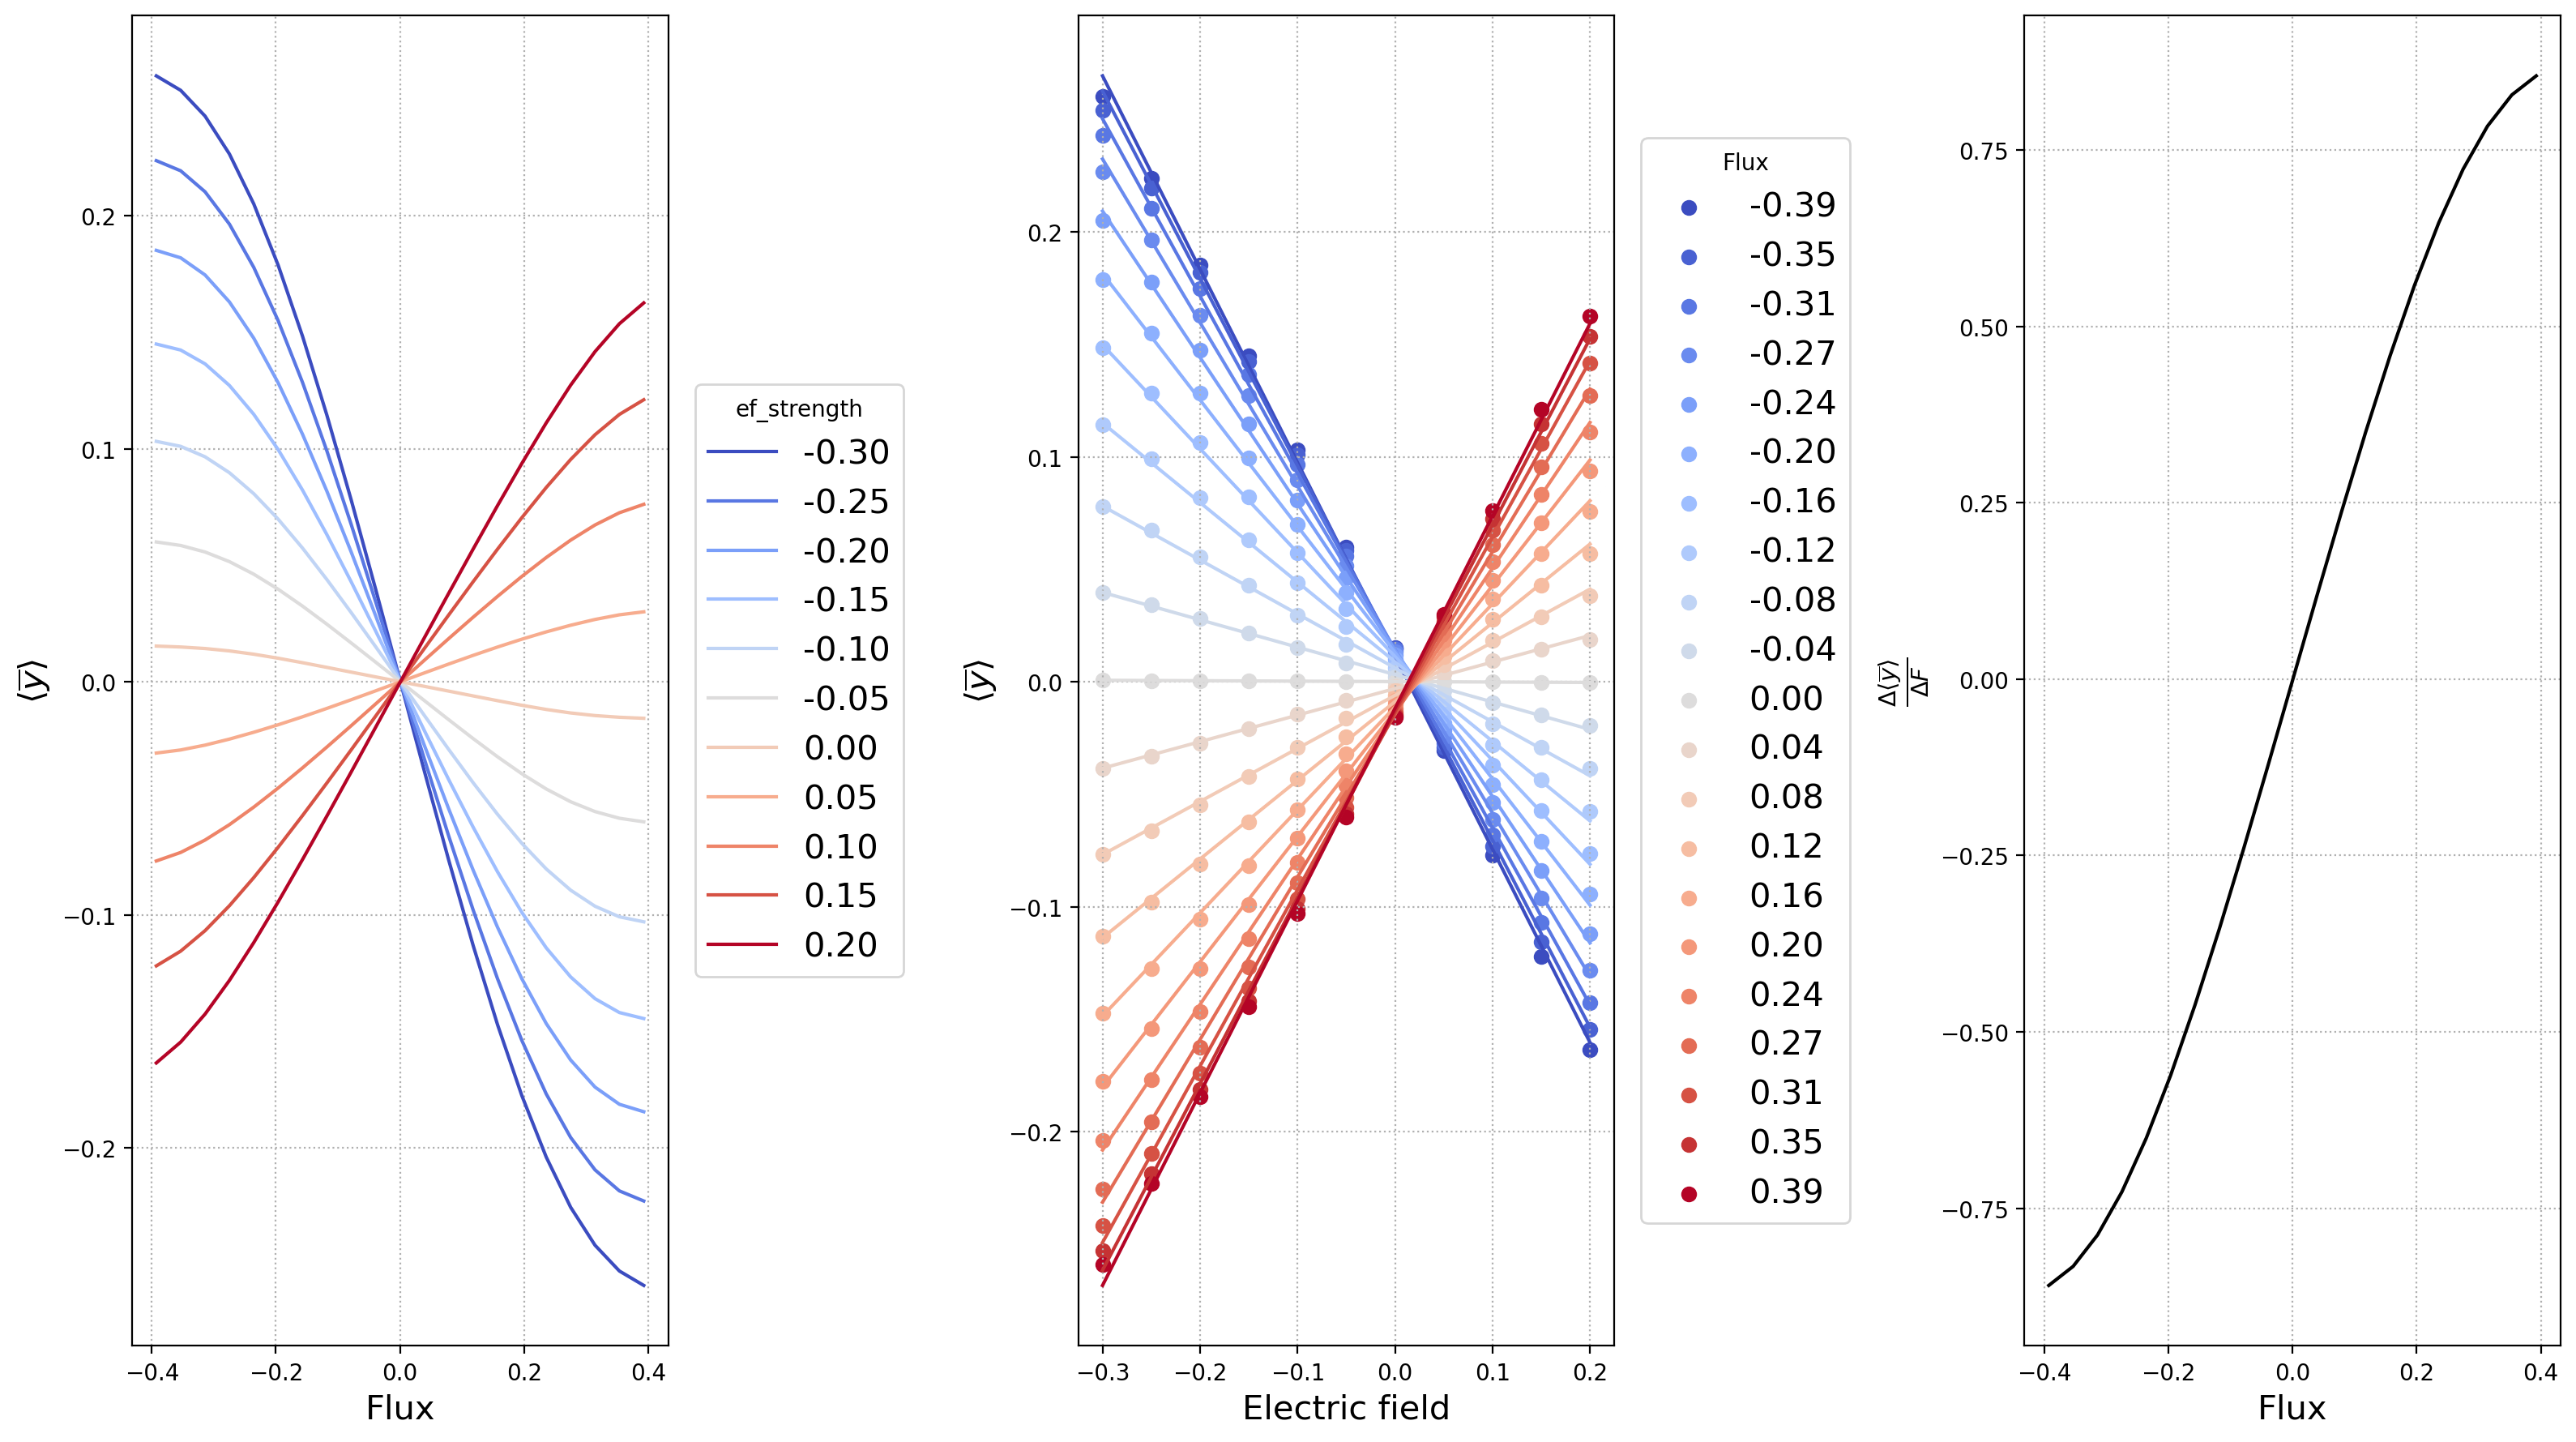

In [6]:
# '0': 4.675 * 2 * pi, '1': 4.5 * 2 * pi, '2': 4.625 * 2 * pi, '3': 4.775 * 2 * pi,
# '4': 4.55 * 2 * pi, '8': 4.725 * 2 * pi, '12': 4.83 * 2 * pi

experiment_config_base = {'launch_code': 5,

                    'chosen_sites': [(3,), (2, 7), (1, 6, 11), (0, 5, 10, 15), (4, 9, 14), (8, 13), (12,)],
                    'site_exc_id': [3], 'site_fock_number': [1], 'site_modul_id': None, 
                    'site_monitor_id_list': [3, 2, 1, 0, 7, 6, 5, 4, 11, 10, 9, 8, 15, 14, 13, 12],

                    'operating_time_points': np.linspace(0, 0.18e3, int(0.18e3 + 1)), # ns
                    'phi_list': np.linspace(-pi / 8, pi / 8, 21), 'ef_strength_list': np.linspace(-0.3, 0.2, 11), # np.linspace(-0.3, 0.2, 11), np.array([-0.3, 0, 0.2])

                    'dc_freqs': {},
                    'modul_ampls': {},
                    'modul_freqs': {},
                    'modul_phases': {},

                    'drive_ampl_factor': None,
                    'drive_ampls': {},
                    'drive_freqs': {},
                    'drive_phases': {}}
experiment_config_list = SetUpExperiment(processor, experiment_config_base)

processor.LaunchExperiment(experiment_config_list)

- It is seen that when electric field is zero there is still transverse deflection of the particle resulting from disorder of the hopping rates. So even at zero e-field inversion symmetry in configuration space is broke. <br>
- At the same time when magnetic field is zero then, as expected, time-reversal symmetry is preserved, hence we are in the axes of parameters of mirror antisymmetry, so there is no transverse deflection at all

### Testing

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:    1.5s
[Parallel(n_jobs=-1)]: Done  30 out of  40 | elapsed:    1.7s remaining:    0.6s
[Parallel(n_jobs=-1)]: Done  35 out of  40 | elapsed:    1.9s remaining:    0.3s
[Parallel(n_jobs=-1)]: Done  40 out of  40 | elapsed:    2.0s finished


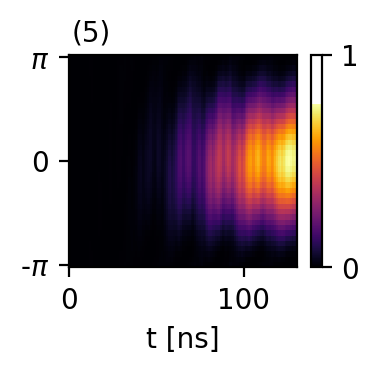

In [ ]:
# '0': 4.675 * 2 * pi, '1': 4.5 * 2 * pi, '2': 4.625 * 2 * pi, '3': 4.775 * 2 * pi,
# '4': 4.55 * 2 * pi, '8': 4.725 * 2 * pi, '12': 4.83 * 2 * pi

experiment_config_base = {'launch_code': 1,

                    'dc_freqs': {'1': 4.5 * 2 * pi, '2': 4.625 * 2 * pi, '5': 4.675 * 2 * pi,
                                 '6': 4.5 * 2 * pi},
                    'modul_ampls': {},
                    'modul_freqs': {},
                    'modul_phases': {'1': 0., '2': 0., '5': 0., '6': 0.},

                    'chosen_sites': [(2,), (1, 6), (5,)],
                    'site_exc_id': 2, 'site_modul_id': 6, 
                    'site_monitor_id_list': [5],

                    'operating_time_points': np.linspace(0, 0.13e3, int(0.13e3 + 1)), # ns
                    'phi_list': np.linspace(-pi, pi, 40), 'ef_strength_list': None,

                    'drive_ampl_factor': None, 'drive_ampls': {}, 'drive_freqs': {}, 'drive_phases': {}}
experiment_config_list = SetUpExperiment(device_config, experiment_config_base)

processor.LaunchExperiment(experiment_config_list)

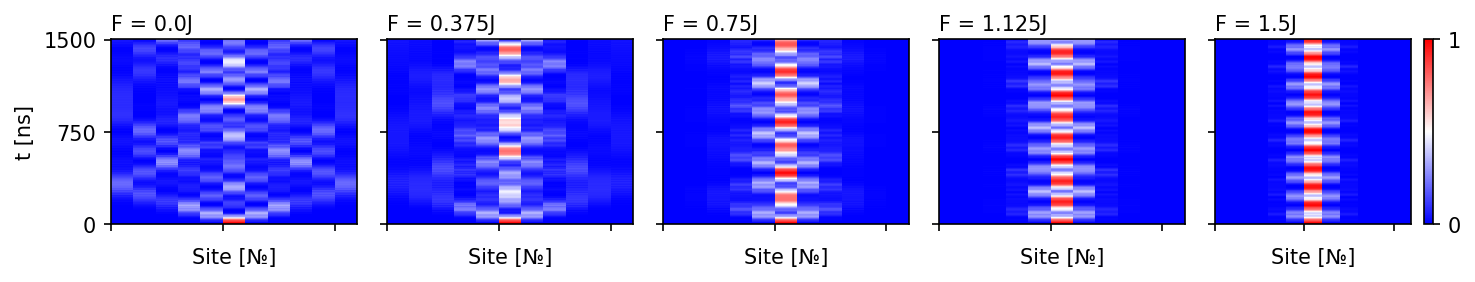

In [ ]:
# '0': 4.675 * 2 * pi, '1': 4.5 * 2 * pi, '2': 4.625 * 2 * pi, '3': 4.775 * 2 * pi,
# '4': 4.55 * 2 * pi, '5': 4.675 * 2 * pi, '6': 4.5 * 2 * pi, '7': 4.625 * 2 * pi, '8': 4.725 * 2 * pi,
# '9': 4.55 * 2 * pi, '10': 4.675 * 2 * pi, '11': 4.5 * 2 * pi, '12': 4.83 * 2 * pi, '13': 4.725 * 2 * pi,
# '14': 4.55 * 2 * pi, '15': 4.675 * 2 * pi

experiment_config_base = {'launch_code': 2,

                    'dc_freqs': {'3': 4.775 * 2 * pi, '2': 4.625 * 2 * pi, '7': 4.625 * 2 * pi,
                                 '1': 4.5 * 2 * pi, '11': 4.5 * 2 * pi, '0': 4.675 * 2 * pi,
                                 '15': 4.675 * 2 * pi, '4': 4.55 * 2 * pi, '14': 4.55 * 2 * pi,
                                 '8': 4.725 * 2 * pi, '13': 4.725 * 2 * pi},
                    'modul_ampls': {'3': 0 * 2 * pi},
                    'modul_freqs': {'3': 0 * 2 * pi},
                    'modul_phases': {'0': 0., '1': 0., '2': 0., '3': 0., '4': 0., '5': 0., '6': 0., '7': 0., '8': 0.,
                                     '9': 0., '10': 0., '11': 0, '12': 0., '13': 0., '14': 0., '15': 0.},

                    'chosen_sites': [(3,), (2, 7), (1, 11), (0, 15), (4, 14), (8, 13)],
                    'site_exc_id': 3, 'site_modul_id': None, 'site_monitor_id_list': [8, 4, 0, 1, 2, 3, 7, 11, 15, 14, 13],

                    'operating_time_points': np.linspace(0, 1.5e3, int(1.5e3 + 1)), # ns
                    'phi_list': None, 'ef_strength_list': np.linspace(0, 1.5, 5),
                    
                    'drive_ampl_factor': None, 'drive_ampls': {}, 'drive_freqs': {}, 'drive_phases': {}}
experiment_config_list = SetUpExperiment(device_config, experiment_config_base)

results = processor.LaunchExperiment(experiment_config_list)

## After all
- study Berry phase & explain cyclotron-like trajectory in Hall effect <br>
- try to include next-nearest couplings & calibrate system for them -> verify experiments <br>
- verify for different excitation sites in interference ✅(just in dev; mb interpret more deeply later) <br>
- unable to create intricate chain using parametric coupling; try to simulate lattice with tunable couplers in the future <br>